
<a id="summary"></a>

## Notebook 3 — RFM scoring & clustering (behavioral segments)

**v1.** This notebook engineers **RFM features** at **customer** grain (on top of completed transactions), prepares **clustering** on behavioral patterns, and targets roadmap **Q6–Q10** from `docs/fintech-ai-segmentation-summary.md`.

### How this notebook is organized

**Jump to parts:** 

1. [Part 1 — RFM design & data loading](#part-1)
2. [Part 2 — RFM metrics and Feature Engineering](#part-2)
3. [Part 3 — clustering & segment profiles](#part-3)
4. [Part 4 — products & utilization](#part-4)

**Part 1 — RFM design & data loading**

1.1 [RFM ranking criteria (locked definitions)](#rfm-criteria)
1.2 [Load raw tables from Supabase](#q1)
1.3 [Join transactions to customer attributes](#q2)
1.4 [Analysis window & transaction month buckets](#q3)

---

### Objectives

- **This pass:** Document **RFM criteria**, import libraries, load **`customers_raw`**, **`transactions_raw`**, **`products_raw`**, **`customer_products_raw`**, build **`df_tx`**, restrict to the **2024-03–2026-02** analysis window, and pin **`as_of_date`**. **F** and **M** use the **full retained history** within that window (no extra 12-month cap).
- **Later:** Quintile scores, K-Means / segments, answers to Q6–Q10 (including product counts and credit utilization when features exist).

### Business questions (Behavioral Intelligence)

6. Who are our most valuable customers right now?
7. What behavioral patterns define each customer segment?
8. What is the RFM profile of each segment?
9. Do high-engagement customers own more products?
10. How does credit utilization vary across segments? *(requires engineered `customers_features` or a documented proxy — see [RFM criteria](#rfm-criteria).)*

### Expected output

- **`df_tx`**: completed transactions joined to customers, restricted to **`transaction_datetime` in [2024-03-01, 2026-03-01)** (Mar 2024–Feb 2026 inclusive by month).
- **`as_of_date`**: reference instant for **recency**; **frequency** and **monetary** are computed over **all** completed transactions in that window with `transaction_datetime` ≤ `as_of_date`.
- **`df_products`**, **`df_customer_products`**: for product-ownership analysis (Q9).
- Later: per-customer **`recency_days`**, **`frequency`** (count), **`monetary`** (sum), quintile scores, **`rfm_score`**, **`predicted_segment`**.



<a id="rfm-criteria"></a>

### RFM ranking criteria (v1)

These definitions stay aligned with [`2.EDA_cohort_analysis.ipynb`](2.EDA_cohort_analysis.ipynb) calendar rules and with [`docs/notebooks-roadmap.md`](docs/notebooks-roadmap.md) Notebook 4.


| Topic | Rule |
|-------|------|
| **Analysis window** | Keep completed transactions with **`transaction_datetime`** in **[2024-03-01, 2026-03-01)** (calendar months **2024-03** through **2026-02**). Then derive `transaction_month` / `registration_month`. |
| **`as_of_date`** | **`max(transaction_datetime)`** on those retained **`df_tx`** rows (end of the analysis window for RFM). |
| **Recency (R)** | Days from **`as_of_date`** to each customer's **last** completed transaction timestamp (`>= 0`). Customers with no transaction in the retained data are out of scope for RFM until handled explicitly. |
| **Frequency (F)** | Count of completed transactions per customer with `transaction_datetime` **≤ `as_of_date`**, over the **full analysis window** (Mar 2024–Feb 2026). |
| **Monetary (M)** | Sum of **`amount`** over the **same rows as F**. Exclude **`transaction_type = 'refund'`** from F and M when that column is present (or net, if you define a refund rule). |
| **Scores 1–5** | **Quintiles** on each dimension among eligible customers: higher score = more recent (lower days), higher frequency, higher monetary. Ties: use `method='first'` in `pandas.qcut` unless we document otherwise. |
| **Combined `rfm_score`** | For ordering: **`100 * R_score + 10 * F_score + M_score`** (so lexicographic R → F → M). For reporting, also keep the three scores separate. |


[↑ Back to summary](#summary)


In [1]:

# ── Importing libraries ──────────────────────────────────────────────────────

import os

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter

from IPython.display import display

sns.set_theme(style="whitegrid")


def format_brl_value(value):
    formatted = f"{value:,.2f}".replace(",", "_").replace(".", ",").replace("_", ".")
    return f"R$ {formatted}"


def format_brl(value, pos):
    return format_brl_value(value)



<a id="part-1"></a>

## Part 1 — RFM design & data loading

**Goal:** pull raw tables from Supabase, build **`df_tx`** (completed transactions + customer attributes), restrict to the **2024-03–2026-02** analysis window, and set **`as_of_date`**.

[↑ Back to summary](#summary)



<a id="q1"></a>

### 1. Load `customers_raw`, `transactions_raw`, `products_raw`, `customer_products_raw` from Supabase

[↑ Back to summary](#summary)


In [2]:

# override=True ensures .env changes are picked up without restarting the kernel
load_dotenv(override=True)

DATABASE_URL = os.environ["SUPABASE_DATABASE_URL"]

engine = create_engine(
    DATABASE_URL,
    pool_pre_ping=True,  # helps avoid stale connections in notebooks
)

sql_customers = text(
    "SELECT\n"
    "  customer_id,\n"
    "  age,\n"
    "  state,\n"
    "  acquisition_channel,\n"
    "  acquisition_cost,\n"
    "  registration_date,\n"
    "  true_segment\n"
    "FROM public.customers_raw\n"
)

df_customers = pd.read_sql(sql_customers, engine)

sql_transactions = text(
    "SELECT\n"
    "  transaction_id,\n"
    "  customer_id,\n"
    "  transaction_datetime,\n"
    "  amount,\n"
    "  transaction_type,\n"
    "  product_type,\n"
    "  channel,\n"
    "  status\n"
    "FROM public.transactions_raw\n"
    "WHERE status = 'completed'\n"
)

df_transactions = pd.read_sql(sql_transactions, engine)

sql_products = text(
    "SELECT\n"
    "  product_id,\n"
    "  product_name,\n"
    "  product_type\n"
    "FROM public.products_raw\n"
)

df_products = pd.read_sql(sql_products, engine)

sql_customer_products = text(
    "SELECT\n"
    "  customer_id,\n"
    "  product_id,\n"
    "  start_date,\n"
    "  is_active\n"
    "FROM public.customer_products_raw\n"
)

df_customer_products = pd.read_sql(sql_customer_products, engine)



In [3]:
print("df_customers:", df_customers.shape)
display(df_customers.head())


df_customers: (8000, 7)


,customer_id,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment
0,0b8f3bda-d929-4111-abd9-992ac76066a9,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active
1,f96dacb9-92bb-4094-977c-0de351bebff0,45,CE,paid_ads,222.02,2023-09-30 00:00:00+00:00,high_value_active
2,137009b3-c01b-4cb1-9b73-6096c094ea87,29,BA,referral,39.81,2022-09-22 00:00:00+00:00,high_value_active
3,15882a3d-ff7e-44ac-9a9c-54028f22d4e6,38,MS,referral,52.54,2023-05-06 00:00:00+00:00,high_value_active
4,4ad24923-433d-4cbb-a335-3603a07f764c,29,PE,paid_ads,199.99,2023-10-16 00:00:00+00:00,high_value_active


In [4]:
print("df_transactions (completed):", df_transactions.shape)
display(df_transactions.head())


df_transactions (completed): (2031570, 8)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status
0,8d3cb3b5-f56e-4ddc-ad41-2eab2fbf71ba,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 03:24:00+00:00,229.31,purchase,wallet,online,completed
1,5786c86a-f490-4350-ae2c-13a27c6379f6,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-23 05:05:00+00:00,197.42,fee,wallet,in_app,completed
2,9563633f-b989-463c-b79d-50afe80560c0,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-24 10:12:00+00:00,163.86,transfer,wallet,in_app,completed
3,40a150ce-03f8-457c-8dfd-59fd4b178628,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-30 14:45:00+00:00,200.62,purchase,credit_card,online,completed
4,f7d2b200-c68e-4335-8461-17c754ed6028,0b8f3bda-d929-4111-abd9-992ac76066a9,2023-06-28 16:34:00+00:00,177.76,fee,investment,online,completed


In [5]:
print("df_products:", df_products.shape)
display(df_products.head())


df_products: (5, 3)


,product_id,product_name,product_type
0,217b207a-9807-4785-8d72-7efd0feee310,Digital Wallet,wallet
1,c0f2fd1e-82b9-436e-ab54-ebbe8cf575e0,SynaptiqPay Credit Card,credit_card
2,1a669298-c14d-40ca-886d-080df620b493,Investment Account,investment
3,8220d026-90e5-4f54-81ef-a00aca9ce261,Device Insurance,insurance
4,9b0a3075-54a6-4f6a-bc64-ccd32b737ab7,Personal Loan,loan


In [6]:
print("df_customer_products:", df_customer_products.shape)
display(df_customer_products.head())


df_customer_products: (19902, 4)


,customer_id,product_id,start_date,is_active
0,0b8f3bda-d929-4111-abd9-992ac76066a9,217b207a-9807-4785-8d72-7efd0feee310,2024-09-21 00:00:00+00:00,True
1,0b8f3bda-d929-4111-abd9-992ac76066a9,c0f2fd1e-82b9-436e-ab54-ebbe8cf575e0,2025-08-04 00:00:00+00:00,True
2,0b8f3bda-d929-4111-abd9-992ac76066a9,1a669298-c14d-40ca-886d-080df620b493,2026-02-06 00:00:00+00:00,True
3,f96dacb9-92bb-4094-977c-0de351bebff0,217b207a-9807-4785-8d72-7efd0feee310,2024-06-22 00:00:00+00:00,True
4,f96dacb9-92bb-4094-977c-0de351bebff0,c0f2fd1e-82b9-436e-ab54-ebbe8cf575e0,2025-12-16 00:00:00+00:00,True



<a id="q2"></a>

### 2. Join transactions to customer attributes

`df_transactions` is merged with `df_customers` on **`customer_id`** (inner join) so every row carries **`acquisition_channel`**, **`true_segment`**, and **`registration_date`**.

[↑ Back to summary](#summary)


In [7]:
# Join transactions to customer attributes
df_tx = df_transactions.merge(df_customers, on="customer_id", how="inner")



<a id="q3"></a>

### 3. Analysis window & transaction month buckets

Restrict **`df_tx`** to transactions in **2024-03 through 2026-02** (`transaction_datetime` in **[2024-03-01, 2026-03-01)**). Then normalize **`transaction_datetime`** and **`registration_date`** to month-start timestamps and ensure **`amount`** is numeric.

**`as_of_date`** is the maximum **`transaction_datetime`** within this window (end of RFM observation for recency and full-window F/M).

[↑ Back to summary](#summary)


In [32]:

# Analysis window: Mar 2024 through Feb 2026 (inclusive on transaction month)
# Keep rows with transaction_datetime in [2024-03-01, 2026-03-01)
WINDOW_START = pd.Timestamp("2024-03-01")
WINDOW_END_EXCL = pd.Timestamp("2026-03-01")

_tx = df_tx["transaction_datetime"]
if isinstance(_tx.dtype, pd.DatetimeTZDtype):
    _tx = _tx.dt.tz_convert("UTC").dt.tz_localize(None)

_window_mask = (_tx >= WINDOW_START) & (_tx < WINDOW_END_EXCL)
_n_before = len(df_tx)
df_tx = df_tx.loc[_window_mask].copy()
print(
    f"Analysis window 2024-03 .. 2026-02: rows {_n_before:,} -> {len(df_tx):,}"
)

# Transaction month (calendar month start)
tx_dt = df_tx["transaction_datetime"]
if isinstance(tx_dt.dtype, pd.DatetimeTZDtype):
    tx_dt = tx_dt.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["transaction_month"] = tx_dt.dt.to_period("M").dt.to_timestamp()

# Registration month (cohort month anchor)
reg = df_tx["registration_date"]
if isinstance(reg.dtype, pd.DatetimeTZDtype):
    reg = reg.dt.tz_convert("UTC").dt.tz_localize(None)

df_tx["registration_month"] = reg.dt.to_period("M").dt.to_timestamp()

# Amount numeric
df_tx["amount"] = pd.to_numeric(df_tx["amount"], errors="coerce")

print("df_tx (joined, windowed):", df_tx.shape)
display(df_tx.head())

# Latest calendar month observed in this window
latest_complete_month = df_tx["transaction_month"].max().to_period("M")
print("latest_complete_month:", latest_complete_month)

# Reference instant for RFM (recency anchor; F/M use full retained history up to here)
as_of_date = df_tx["transaction_datetime"].max()
print("as_of_date:", as_of_date)


Analysis window 2024-03 .. 2026-02: rows 1,342,806 -> 1,342,806
df_tx (joined, windowed): (1342806, 16)


,transaction_id,customer_id,transaction_datetime,amount,transaction_type,product_type,channel,status,age,state,acquisition_channel,acquisition_cost,registration_date,true_segment,transaction_month,registration_month
313,843e890a-5778-4e57-8c52-39c92c39c3db,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-06 15:41:00+00:00,267.00,purchase,wallet,card_present,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
314,279635b4-9624-4560-9a23-7e7c1a0c0afa,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-26 10:19:00+00:00,135.31,purchase,wallet,online,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
315,7088a830-6b42-426b-81a0-1390b4f29a3c,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-07 21:17:00+00:00,270.30,purchase,wallet,in_app,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
316,0030e3d0-ab33-43f2-8c42-08fdfac93c48,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-25 07:42:00+00:00,203.04,purchase,investment,online,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01
317,147004c5-c0d3-4b61-8944-3d67cc83d131,0b8f3bda-d929-4111-abd9-992ac76066a9,2024-03-14 14:50:00+00:00,153.28,transfer,credit_card,online,completed,39,RS,organic,27.79,2023-06-23 00:00:00+00:00,high_value_active,2024-03-01,2023-06-01


latest_complete_month: 2026-02
as_of_date: 2026-02-28 23:58:00+00:00


/var/folders/sc/vkhmk96s2m7f0hcwdzmnr2bw0000gn/T/ipykernel_9332/3296164742.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vc_tx_type.index, y=vc_tx_type.values, palette="Blues_d")


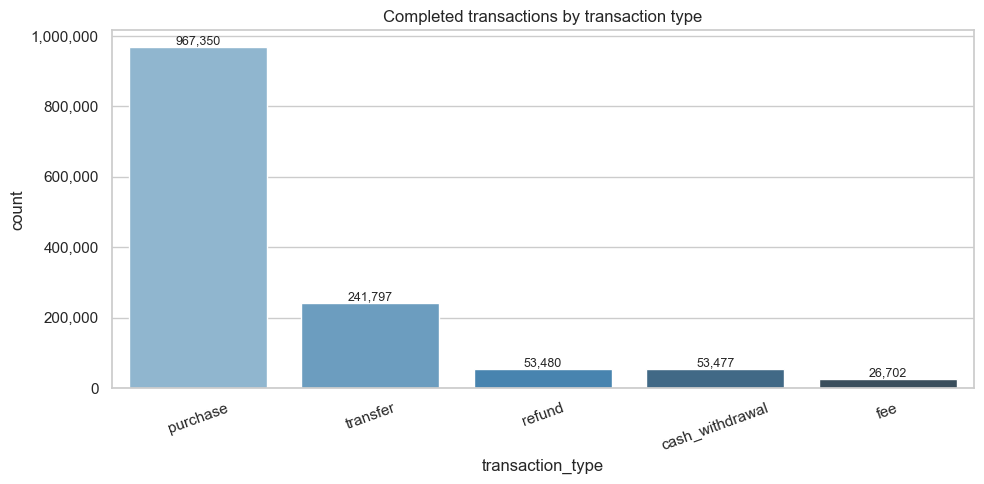

transaction_type
purchase           967350
transfer           241797
refund              53480
cash_withdrawal     53477
fee                 26702
Name: count, dtype: int64

In [33]:

# Transaction type distribution (absolute counts)
vc_tx_type = (
    df_tx["transaction_type"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))
ax = sns.barplot(x=vc_tx_type.index, y=vc_tx_type.values, palette="Blues_d")
ax.set_title("Completed transactions by transaction type")
ax.set_xlabel("transaction_type")
ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=20)
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}"))

for i, v in enumerate(vc_tx_type.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

vc_tx_type


This chart above shows a strongly purchase-led transaction mix: purchases account for the vast majority of completed operations, while transfer form a secondary tier. Fee, cash withdrawal and refund are comparatively small, which is expected operationally, but still useful to monitor as quality signals. Overall, user behavior looks concentrated in value-generating transactions, with limited reversal activity.

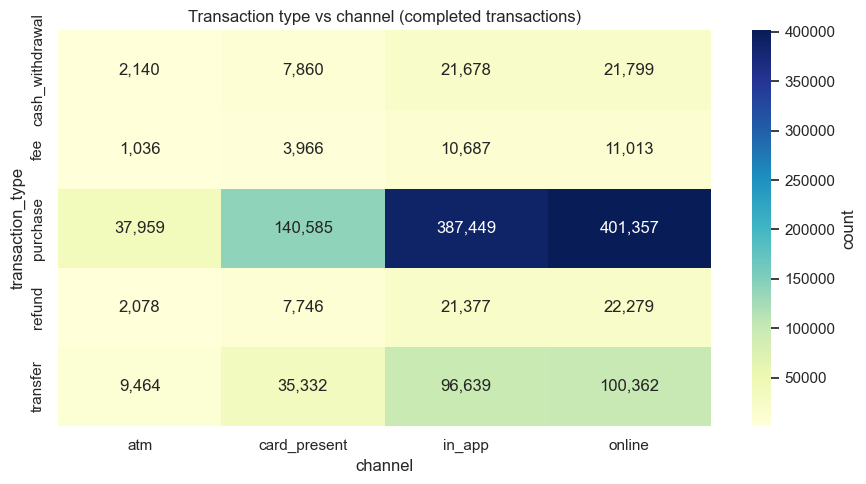

In [34]:
# Heatmap: transaction_type x channel (absolute counts)
tx_type_channel = pd.crosstab(
    df_tx["transaction_type"],
    df_tx["channel"],
).sort_index()

plt.figure(figsize=(9, 5))
ax = sns.heatmap(
    tx_type_channel,
    annot=True,
    fmt=",d",
    cmap="YlGnBu",
    cbar_kws={"label": "count"},
)
ax.set_title("Transaction type vs channel (completed transactions)")
ax.set_xlabel("channel")
ax.set_ylabel("transaction_type")

plt.tight_layout()
plt.show()


**Purchases** dominate overall volume. For purchases, **online** (401,357) slightly edges **in_app** (387,449); **card_present** (140,585) is next, and **atm** (37,959) is far smaller. **Transfers** follow the same digital skew (**online** 100,362 vs **in_app** 96,639). **ATM** is the smallest channel for every transaction type—physical rails are niche, not the default journey.

**Actionable insight:** Invest jointly in **web + app** purchase funnels (A/B by step, latency, failures) since both carry the majority of revenue-adjacent volume. Treat **card_present** as a partner/merchant lane worth its own CAC and experience KPIs. Revisit **ATM** economics—optimize for a small “cash access” segment or trim fixed cost if volume stays flat. For **transfers**, prioritize digital capabilities (limits, scheduling, instant settlement) where users already cluster.

**Segmentation note:** Channel *ranking* looks similar across transaction types (digital first, ATM last), so clusters will likely separate more on **intensity, ticket, and product mix** than on a radically different channel preference—use channel shares as supporting features alongside RFM.


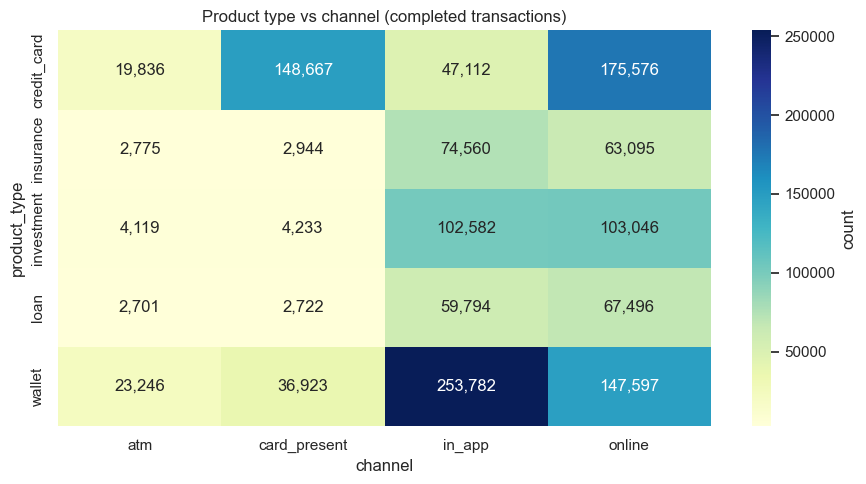

In [35]:
# Heatmap: product_type x channel (absolute counts)
tx_type_channel = pd.crosstab(
    df_tx["product_type"],
    df_tx["channel"],
).sort_index()

plt.figure(figsize=(9, 5))
ax = sns.heatmap(
    tx_type_channel,
    annot=True,
    fmt=",d",
    cmap="YlGnBu",
    cbar_kws={"label": "count"},
)
ax.set_title("Product type vs channel (completed transactions)")
ax.set_xlabel("channel")
ax.set_ylabel("product_type")

plt.tight_layout()
plt.show()


Wallet concentrates in in_app and online, which matches a mobile-first, everyday payments story—prioritize app/Web reliability, limits, and instant notifications on those rails. Credit card activity is relatively strong on card_present and online, so treat in-store and e-commerce partnerships as first-class journeys, not only app flows. Investment, insurance, and loan skew heavily digital (in_app / online) with modest ATM / card_present use—optimize for remote onboarding, education, and frictionless digital servicing; physical channels are niche for these lines.

Actionable insight: Set per-product channel KPIs (conversion, ticket, failure rate) instead of one global funnel: wallet = app/Web growth; credit card = card_present + online acceptance; long-tail products = digital origination and support. Use this matrix to decide where marketing spend and engineering capacity go per product family, and to spot misrouting (e.g., high ATM wallet volume) for fraud or UX review.



<a id="part-2"></a>

## Part 2 — RFM metrics and Feature Engineering

**Goal:** compute customer-level **RFM metrics** from retained completed transactions, engineer supporting **behavioral features** for clustering, and prepare a clean feature matrix for segmentation analysis.

[↑ Back to summary](#summary)

### Checkpoint — customer feature matrix

We build **`df_features`** with `build_customer_feature_matrix(...)`: all **numeric** inputs (behavioral RFM, tenure, refund rate, etc.). **No labels** are passed into this matrix for clustering downstream.


In [54]:
from pathlib import Path
import sys

# Make local src package importable when notebook kernel is not launched via Poetry.
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if src_path.exists() and str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

import importlib
import fintech_ai_segmentation.rfm_features as rfm

rfm = importlib.reload(rfm)
build_customer_feature_matrix = rfm.build_customer_feature_matrix
build_preprocessing_pipeline = rfm.build_preprocessing_pipeline
drop_correlated_splits = rfm.drop_correlated_splits

df_features = build_customer_feature_matrix(
    df_tx,
    df_customer_products,
    df_customers,
    as_of_date,
)
print("df_features shape:", df_features.shape)
display(df_features.head())


df_features shape: (8000, 17)


,customer_id,age,acquisition_cost,tenure_days,recency_days,frequency_total,monetary_total,monetary_purchase,monetary_transfer,monetary_cash_withdrawal,refund_rate,avg_ticket,avg_days_between_tx,products_owned,monetary_purchase_share,monetary_transfer_share,monetary_cash_withdrawal_share
0,0b8f3bda-d929-4111-abd9-992ac76066a9,39,27.79,981.0,28.0,780.0,174621.79,130432.68,31416.73,7130.89,0.042945,223.874090,0.899945,3.0,0.746944,0.179913,0.040836
1,f96dacb9-92bb-4094-977c-0de351bebff0,45,222.02,882.0,0.0,821.0,184915.37,137283.98,36888.43,6389.74,0.043124,225.231876,0.889248,3.0,0.742415,0.199488,0.034555
2,137009b3-c01b-4cb1-9b73-6096c094ea87,29,39.81,1255.0,243.0,565.0,129816.47,99274.61,19544.12,7518.31,0.042373,229.763664,0.859790,1.0,0.764730,0.150552,0.057915
3,15882a3d-ff7e-44ac-9a9c-54028f22d4e6,38,52.54,1029.0,28.0,742.0,163106.58,119394.23,29866.83,7399.50,0.041344,219.820189,0.945594,4.0,0.732001,0.183112,0.045366
4,4ad24923-433d-4cbb-a335-3603a07f764c,29,199.99,866.0,1.0,827.0,182653.19,133130.91,36654.15,8658.80,0.037253,220.862382,0.881939,2.0,0.728873,0.200676,0.047406


### Clustering sample, composition shares, and split pruning

- **Filter:** keep customers with **`frequency_total >= 1`** (at least one non-refund transaction in the analysis window).
- **Composition:** **`monetary_*_share`** columns come from **`add_monetary_type_shares`** in [`rfm_features.py`](../../src/fintech_ai_segmentation/rfm_features.py) (called by **`build_customer_feature_matrix`**) — purchase / transfer / cash withdrawal shares of total spend, capturing *how* the wallet is used, not only intensity.
- **Prune:** `drop_correlated_splits` removes raw monetary split columns that are almost perfectly aligned with **`monetary_total`**, to avoid double-weighting spend in Euclidean distance.


In [66]:
# Reload module so we always pick up the current ``drop_correlated_splits``
# (re-assigning ``drop_correlated_splits = rfm...`` in an earlier cell is easy to stale-cache).
import importlib

import fintech_ai_segmentation.rfm_features as rfm

rfm = importlib.reload(rfm)

df_clustering = df_features.loc[df_features["frequency_total"] >= 1].copy()
n_all = len(df_features)
n_clustering = len(df_clustering)

df_clustering, dropped_cols, corr_monetary_splits = rfm.drop_correlated_splits(
    df_clustering, threshold=0.9
)

if corr_monetary_splits is not None:
    display(
        corr_monetary_splits.style.format("{:.4f}").set_caption(
            "Pearson correlation: monetary_total vs raw split columns (before drop)"
        )
    )

display(
    pd.DataFrame(
        [
            {
                "customers_all": n_all,
                "clustering_n_freq_ge_1": n_clustering,
                "n_split_cols_dropped": len(dropped_cols),
            }
        ]
    )
)

if dropped_cols:
    display(pd.DataFrame({"dropped_split_column": dropped_cols}))
else:
    display(pd.DataFrame({"note": ["No raw split columns dropped at threshold 0.9."]}))


,monetary_total,monetary_purchase,monetary_transfer,monetary_cash_withdrawal
monetary_total,1.0000,0.9995,0.9939,0.9682
monetary_purchase,0.9995,1.0000,0.9905,0.9646
monetary_transfer,0.9939,0.9905,1.0000,0.9609
monetary_cash_withdrawal,0.9682,0.9646,0.9609,1.0000


,customers_all,clustering_n_freq_ge_1,n_split_cols_dropped
0,8000,4884,3


,dropped_split_column
0,monetary_purchase
1,monetary_transfer
2,monetary_cash_withdrawal


### Correlation structure (preprocessing inputs)

We inspect **linear** correlations among columns that will enter **`StandardScaler`** (after `log1p` / `sqrt` where configured). **`monetary_total`** is kept in the frame for QC but **excluded** from clustering features to avoid double-counting spend alongside frequency/ticket.


corr(frequency_total, avg_ticket): 0.7934


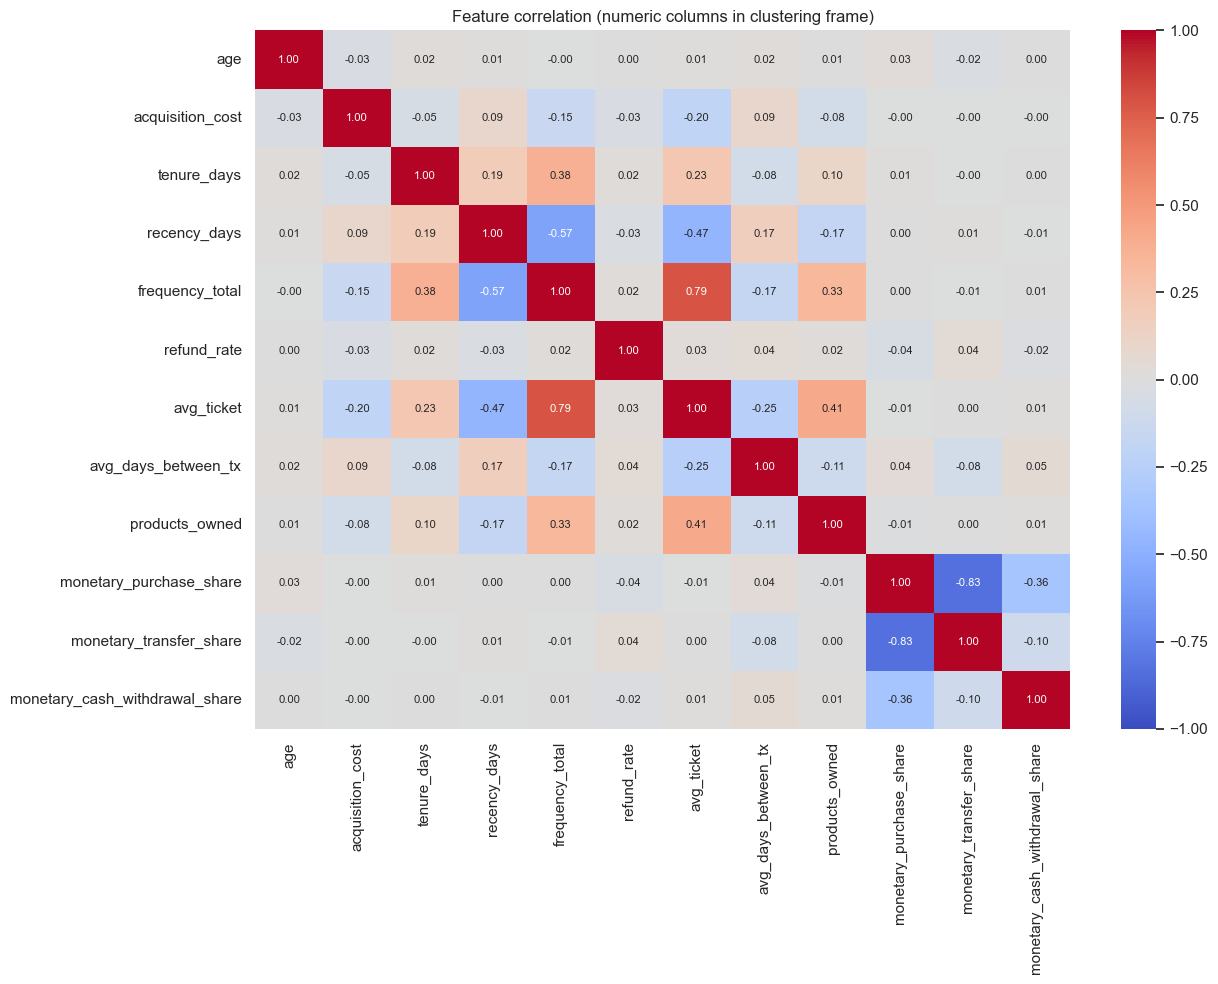

In [56]:
feature_cols = [
    c for c in df_clustering.columns if c not in {"customer_id", "monetary_total"}
]
if {"frequency_total", "avg_ticket"}.issubset(df_clustering.columns):
    corr_freq_ticket = df_clustering[["frequency_total", "avg_ticket"]].corr().iloc[0, 1]
    print(f"corr(frequency_total, avg_ticket): {corr_freq_ticket:.4f}")

_corr = df_clustering[feature_cols].corr()
plt.figure(figsize=(13, 10))
sns.heatmap(
    _corr,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
)
plt.title("Feature correlation (numeric columns in clustering frame)")
plt.tight_layout()
plt.show()


### Raw distributions (before `log1p` / `sqrt`)

Skew-heavy axes (recency, frequency, ticket, …) are **not** Gaussian yet — that is expected. The preprocessing pipeline applies **`log1p`** to those columns before scaling so k-means distances are not dominated by a thin tail of extreme users.


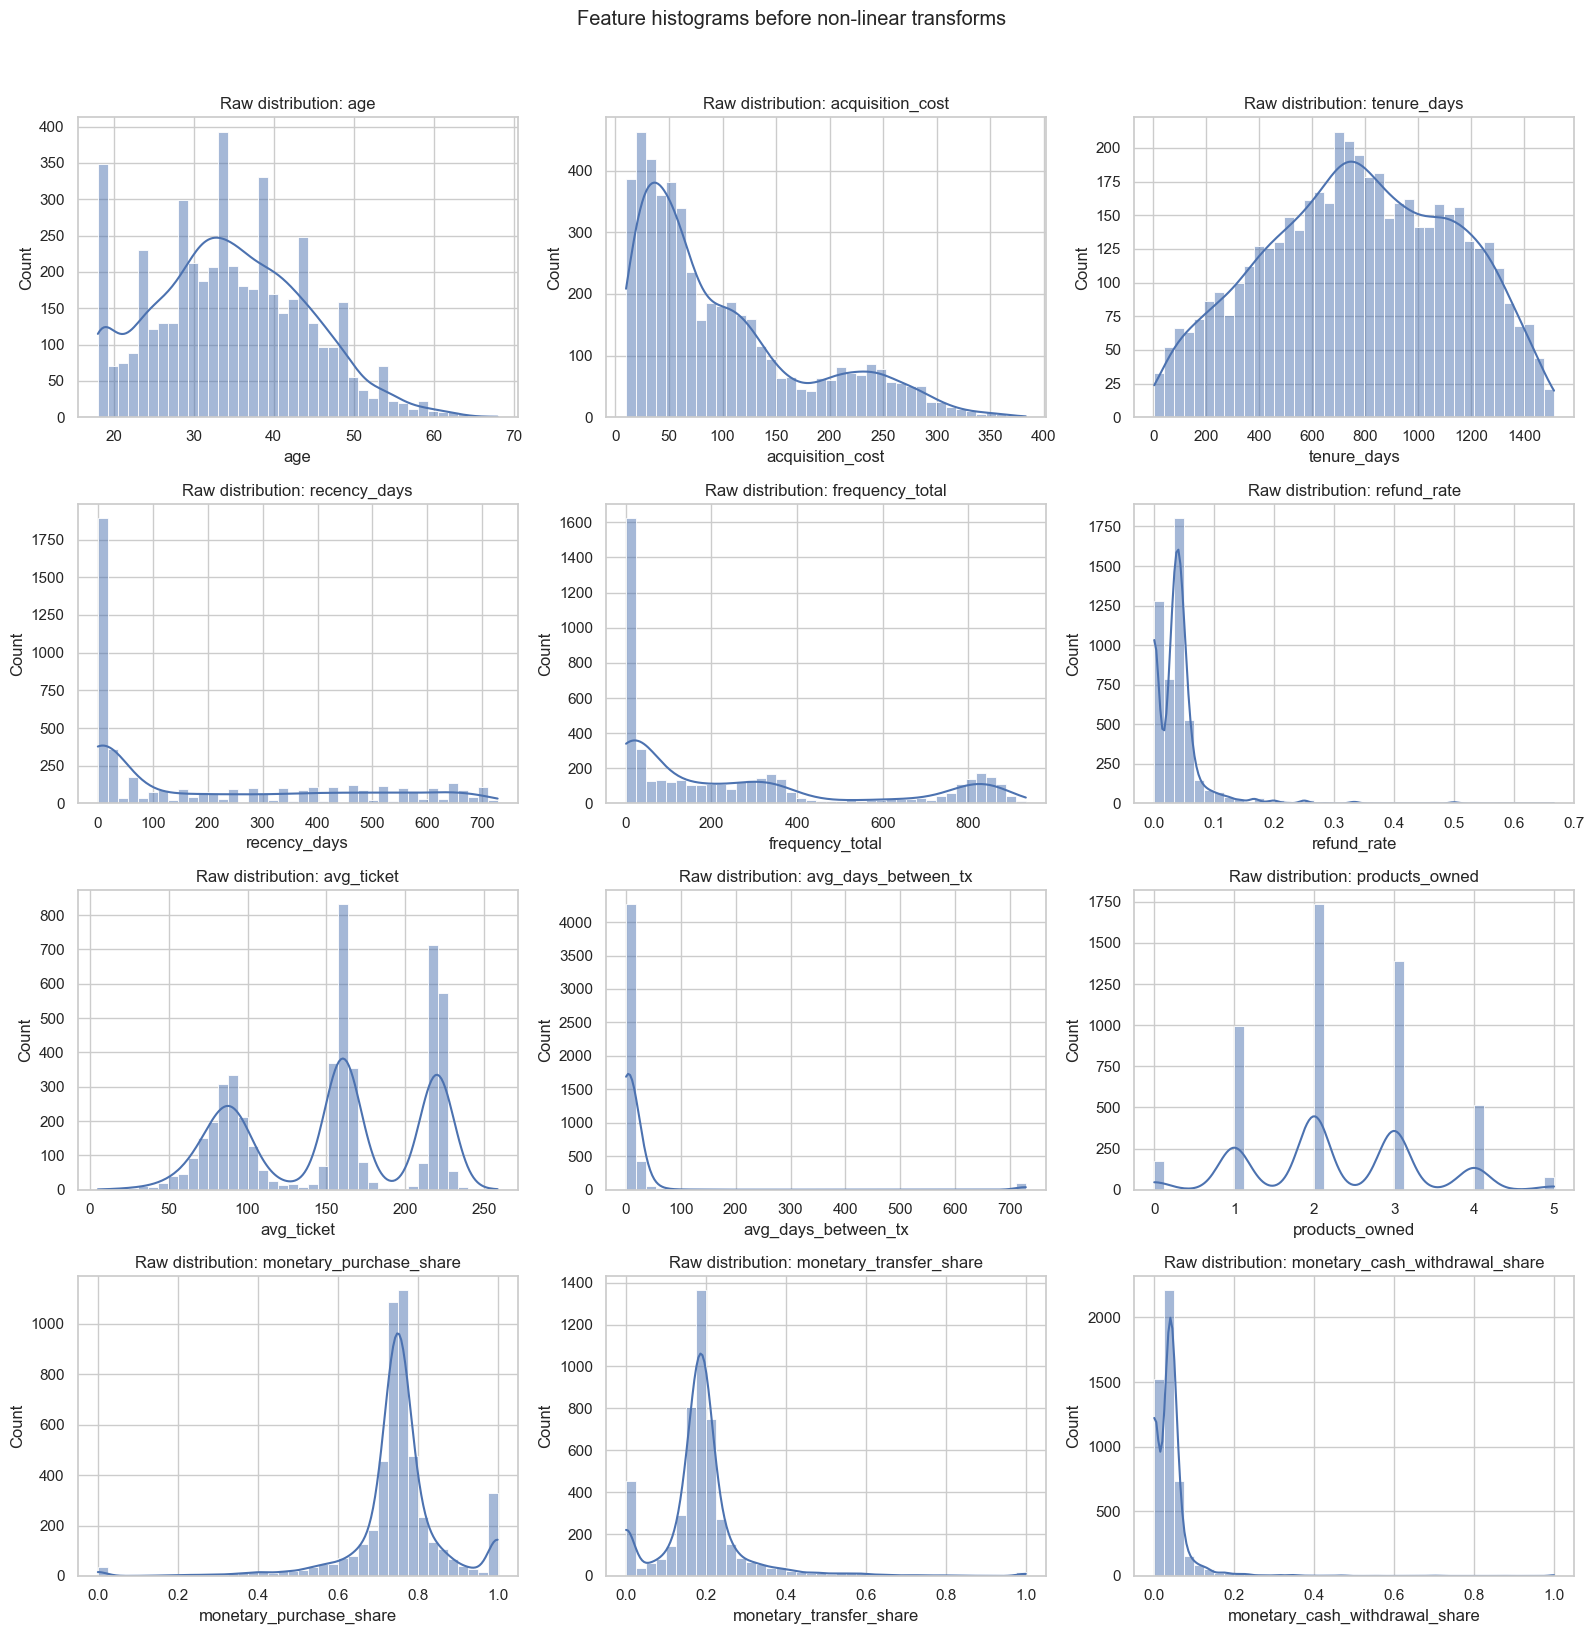

In [57]:
plot_cols = [c for c in feature_cols if c != "customer_id"]
if plot_cols:
    n_cols = 3
    n_rows = int(np.ceil(len(plot_cols) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(plot_cols):
        sns.histplot(df_clustering[col].dropna(), bins=40, kde=True, ax=axes[i])
        axes[i].set_title(f"Raw distribution: {col}")

    for j in range(len(plot_cols), len(axes)):
        axes[j].axis("off")

    plt.suptitle("Feature histograms before non-linear transforms", y=1.02)
    plt.tight_layout()
    plt.show()


### Preprocessing fit (`ColumnTransformer` + `StandardScaler`)

`build_preprocessing_pipeline(feature_cols)` applies **`log1p`** to right-skewed magnitudes, **`sqrt`** to **`refund_rate`**, passes through remaining numeric columns, then **`StandardScaler`** on **all** transformed features — required so k-means is not axis-dominated by BRL scale or mixed units.


In [58]:
preproc = build_preprocessing_pipeline(feature_cols)
X_scaled = preproc.fit_transform(df_clustering[feature_cols])

print("X_scaled shape:", X_scaled.shape)

log_cols = [c for c in rfm.LOG1P_COLS if c in feature_cols]
sqrt_cols = [c for c in rfm.SQRT_COLS if c in feature_cols and c not in log_cols]
pass_cols = [c for c in feature_cols if c not in log_cols and c not in sqrt_cols]
out_cols = log_cols + sqrt_cols + pass_cols

scaled_preview = pd.DataFrame(X_scaled, columns=out_cols)
display(scaled_preview.describe().T[["mean", "std", "min", "max"]].head(12))
display(df_clustering.head())

for _col in [
    "monetary_purchase",
    "monetary_transfer",
    "monetary_cash_withdrawal",
]:
    if _col not in df_clustering.columns:
        df_clustering[_col] = 0.0

X_scaled shape: (4884, 12)


,mean,std,min,max
recency_days,4.655481e-17,1.000102,-1.375276,1.186574
frequency_total,2.793288e-16,1.000102,-1.990366,1.290796
avg_ticket,-6.983221e-16,1.000102,-7.484448,1.435485
avg_days_between_tx,-1.396644e-16,1.000102,-1.230089,4.315252
acquisition_cost,0.000000e+00,1.000102,-2.183421,1.968584
refund_rate,-1.396644e-16,1.000102,-1.475565,5.933799
age,3.273385e-16,1.000102,-1.729271,3.502699
tenure_days,-1.163870e-17,1.000102,-2.178048,2.057824
products_owned,-6.983221e-17,1.000102,-2.139215,2.579812
monetary_purchase_share,-1.083854e-16,1.000102,-5.920320,1.973871


,customer_id,age,acquisition_cost,tenure_days,recency_days,frequency_total,monetary_total,refund_rate,avg_ticket,avg_days_between_tx,products_owned,monetary_purchase_share,monetary_transfer_share,monetary_cash_withdrawal_share
0,0b8f3bda-d929-4111-abd9-992ac76066a9,39,27.79,981.0,28.0,780.0,174621.79,0.042945,223.874090,0.899945,3.0,0.746944,0.179913,0.040836
1,f96dacb9-92bb-4094-977c-0de351bebff0,45,222.02,882.0,0.0,821.0,184915.37,0.043124,225.231876,0.889248,3.0,0.742415,0.199488,0.034555
2,137009b3-c01b-4cb1-9b73-6096c094ea87,29,39.81,1255.0,243.0,565.0,129816.47,0.042373,229.763664,0.859790,1.0,0.764730,0.150552,0.057915
3,15882a3d-ff7e-44ac-9a9c-54028f22d4e6,38,52.54,1029.0,28.0,742.0,163106.58,0.041344,219.820189,0.945594,4.0,0.732001,0.183112,0.045366
4,4ad24923-433d-4cbb-a335-3603a07f764c,29,199.99,866.0,1.0,827.0,182653.19,0.037253,220.862382,0.881939,2.0,0.728873,0.200676,0.047406


**Definitions (feature matrix for clustering)** — All features are numeric. Behavioral: `recency_days`, `frequency_total`, `avg_ticket`, `avg_days_between_tx`, `refund_rate`, monetary mix columns (subject to `drop_correlated_splits`), **`monetary_*_share`**, `tenure_days`, `age`, `acquisition_cost`, `products_owned`. **`monetary_total`** is retained for reconciliation only and **excluded** from `feature_cols`.

### Feature engineering decisions (Part 2 lock-in)

- **Eligibility:** `frequency_total >= 1` defines customers with observable engagement for behavioral clustering.
- **Composition shares:** purchase/transfer/cash withdrawal shares add **orthogonal** “wallet usage pattern” signal on top of intensity.
- **Collinearity:** redundant raw split columns vs `monetary_total` are dropped when |corr| > 0.9.
- **Scaling:** every column in `feature_cols` is transformed then scaled — k-means uses Euclidean distance in this space.

Next: **Part 3** chooses **`k`** using only **internal** diagnostics (inertia, silhouette), fits **k-means**, and profiles clusters for interpretation.


<a id="part-3"></a>

## Part 3 — K-means: choosing **k** and profiling clusters

**Goal:** evaluate cluster structure for **`k = 2..7`** using **inertia** (elbow intuition) and **mean silhouette** (separation quality), inspect **silhouette diagrams** per **`k`**, then fix an **operational `k=3`** and profile clusters.

**Production note:** we do **not** use hidden labels or external “accuracy” metrics here — only geometry in feature space and interpretability of resulting groups.


In [59]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

k_values = list(range(2, 8))
rows = []
labels_by_k = {}

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    labels_by_k[k] = labels
    rows.append(
        {
            "k": k,
            "inertia": float(km.inertia_),
            "silhouette": float(silhouette_score(X_scaled, labels)),
        }
    )

k_eval = pd.DataFrame(rows)
k_eval["inertia_prev"] = k_eval["inertia"].shift(1)
k_eval["inertia_drop_pct"] = (
    (k_eval["inertia_prev"] - k_eval["inertia"]) / k_eval["inertia_prev"]
)

k_silhouette_max = int(k_eval.loc[k_eval["silhouette"].idxmax(), "k"])
k_selected = 3

display(
    k_eval[["k", "inertia", "inertia_drop_pct", "silhouette"]]
    .sort_values("k")
    .reset_index(drop=True)
)
print("Silhouette-max k:", k_silhouette_max)
print("Operational k_selected:", k_selected)


,k,inertia,inertia_drop_pct,silhouette
0,2,44872.174505,NaN,0.291597
1,3,39802.352058,0.112984,0.294530
2,4,36761.912033,0.076388,0.147976
3,5,34056.708759,0.073587,0.156103
4,6,31625.692181,0.071381,0.169174
5,7,29656.980694,0.062250,0.162424


Silhouette-max k: 3
Operational k_selected: 3


### Elbow and mean silhouette (line charts)

Use these plots together: the **elbow** is often ambiguous on marketing/behavioral data; **mean silhouette** penalises overlap but can favour **too few** clusters. The next subsection shows **full silhouette blades** per **`k`** (per-sample coefficients).


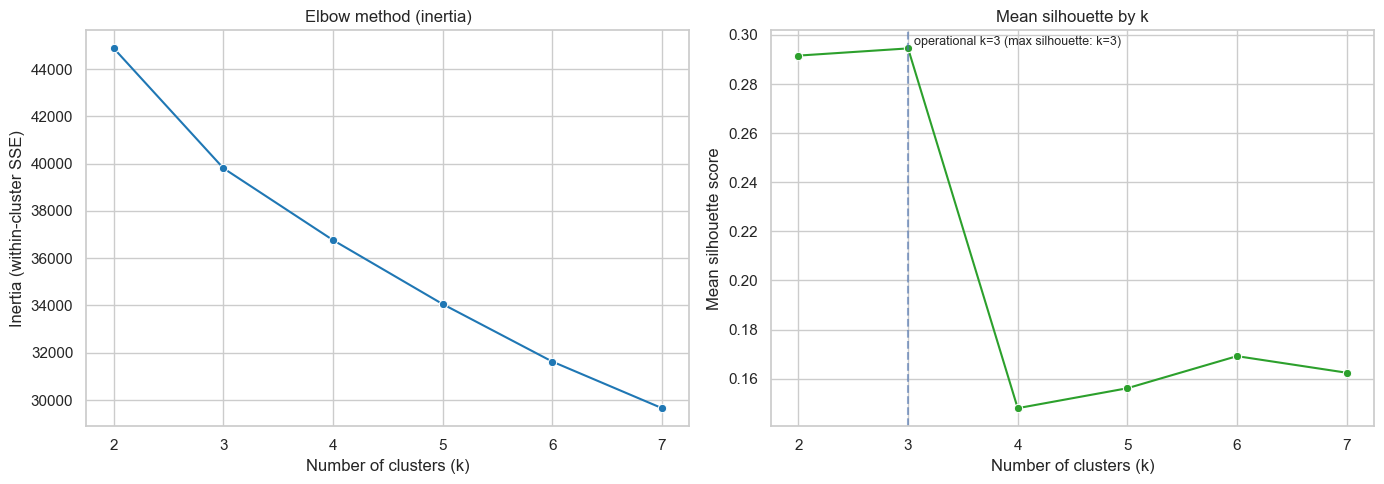

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=k_eval, x="k", y="inertia", marker="o", ax=axes[0], color="#1f77b4")
axes[0].set_title("Elbow method (inertia)")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")

sns.lineplot(
    data=k_eval,
    x="k",
    y="silhouette",
    marker="o",
    ax=axes[1],
    color="#2ca02c",
)
axes[1].set_title("Mean silhouette by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Mean silhouette score")
axes[1].axvline(k_selected, linestyle="--", alpha=0.6)
axes[1].text(
    k_selected + 0.05,
    k_eval["silhouette"].max(),
    f"operational k={k_selected} (max silhouette: k={k_silhouette_max})",
    va="bottom",
    fontsize=9,
)

plt.tight_layout()
plt.show()


### Silhouette diagrams per k (full coefficient profiles)

Each panel sorts samples by cluster blocks. The vertical dashed line is the **mean** silhouette for that **`k`**. Use this to spot **over-splitting** (many small negative slices) vs **stable** separation.


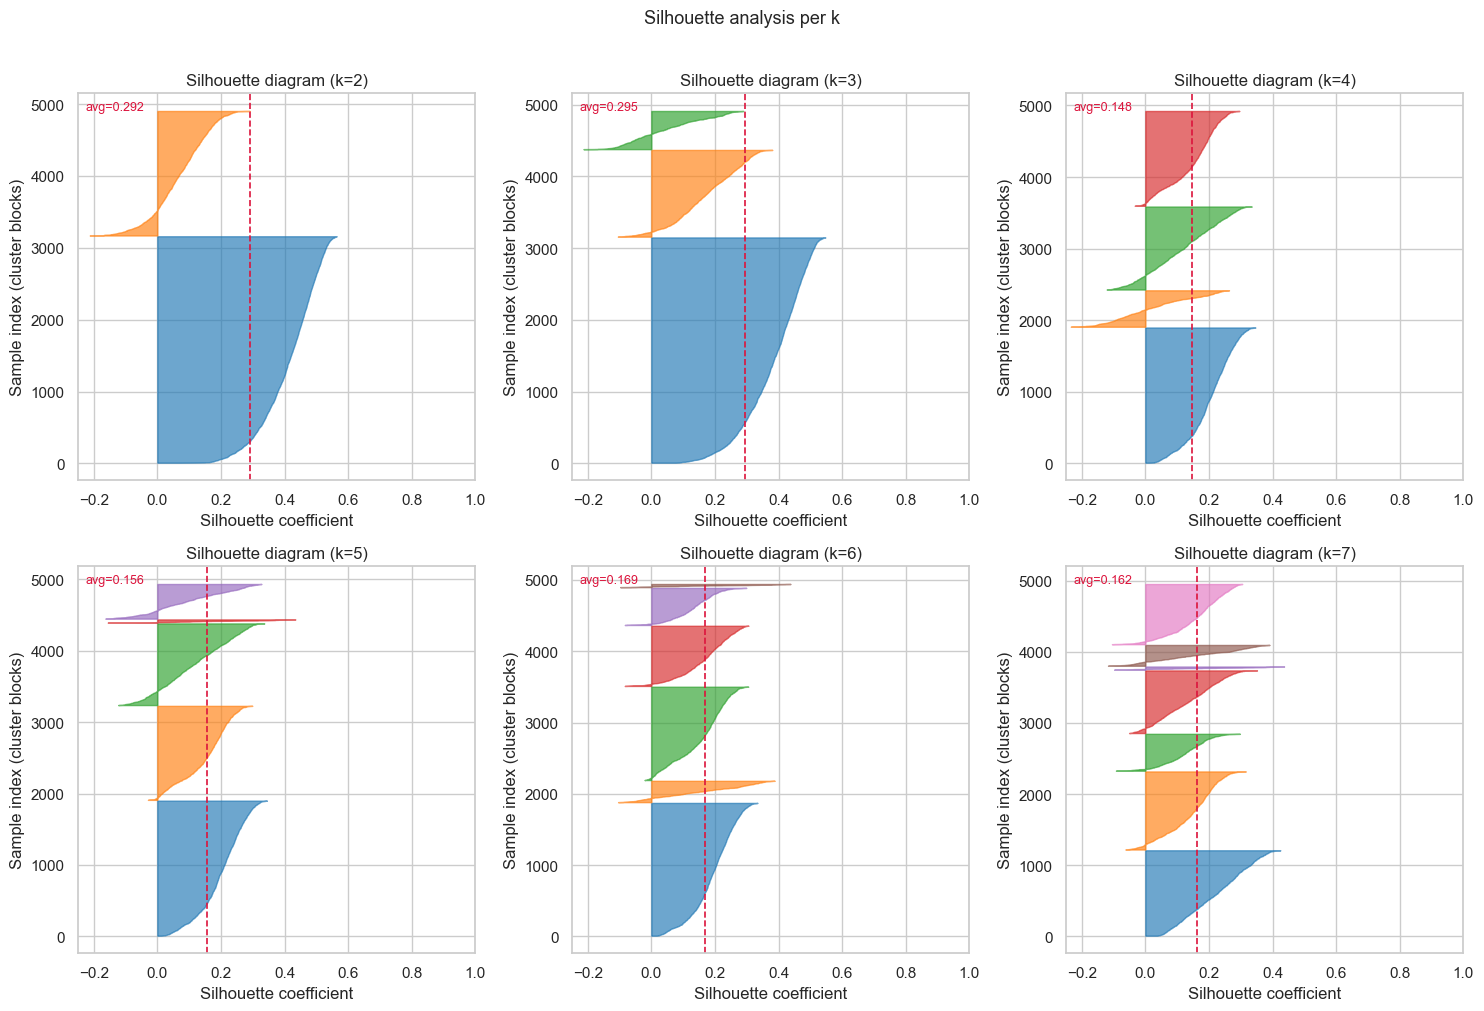

In [61]:
fig_sil, axes_sil = plt.subplots(2, 3, figsize=(15, 10))
axes_sil = axes_sil.flatten()

for ax_idx, k in enumerate(k_values):
    ax = axes_sil[ax_idx]
    cluster_labels = labels_by_k[k]
    sil_avg = float(k_eval.loc[k_eval["k"] == k, "silhouette"].iloc[0])
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)

    y_lower = 10
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        color = plt.cm.tab10(i % 10)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.65,
        )
        y_lower = y_upper + 10

    ax.axvline(x=sil_avg, color="crimson", linestyle="--", linewidth=1.2)
    ax.set_title(f"Silhouette diagram (k={k})")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Sample index (cluster blocks)")
    ax.set_xlim(-0.25, 1.0)
    ax.text(
        0.02,
        0.98,
        f"avg={sil_avg:.3f}",
        transform=ax.transAxes,
        va="top",
        fontsize=9,
        color="crimson",
    )

plt.suptitle("Silhouette analysis per k", y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


### Chart interpretation — elbow, mean silhouette, and silhouette diagrams

**Elbow (inertia)** — Inertia always decreases as **`k`** increases. Look for **diminishing returns** (successive merges of inertia drops), but behavioral datasets often yield a **soft** elbow.

**Mean silhouette** — Summarises how cleanly points match their nearest cluster vs neighbours. Higher is better, but the maximising **`k`** can be **too coarse** for CRM actions.

**Silhouette diagrams** — Reveal **per-cluster** weakness: wide negative mass in a cluster means that group is not well-separated in the current feature space.

**Decision (this notebook):** we lock **`k = k_selected = 3`** as the operational compromise between separation quality and **actionable** granularity (three differentiated engagement/value postures for SynaptiqPay). If mean silhouette peaks at **`k=2`**, that is noted, but **`k=3`** is retained for business usability.


### Decision checkpoint — fit k-means at operational k

We fit **one** production-style model at **`k = k_selected`**, assign **`cluster_k3`**, and profile clusters below (PCA is **visualisation only** — not used to fit k-means).


In [62]:
k_fit = int(k_selected)
km3 = KMeans(n_clusters=k_fit, random_state=42, n_init=20)
labels_k3 = km3.fit_predict(X_scaled)

cluster_sizes = pd.Series(labels_k3).value_counts().sort_index()
print("Cluster sizes (k=%d):" % k_fit)
print(cluster_sizes.to_string())


Cluster sizes (k=3):
0    3141
1    1210
2     533


### Visualising clusters (PCA for 2D projection + feature profiles)

Two complementary views:

- **2D PCA scatter** of **`X_scaled`** — helpful to eyeball overlap; variance explained is usually modest because behavior is high-dimensional.
- **Boxplots + mean/median table** on interpretable raw features (including **`monetary_*_share`**) — primary business readout.


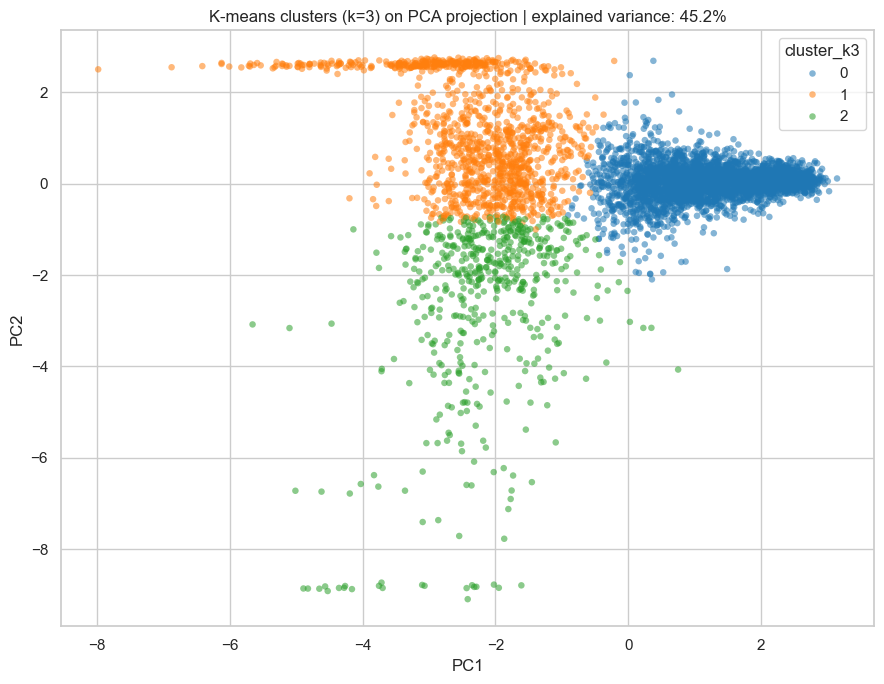

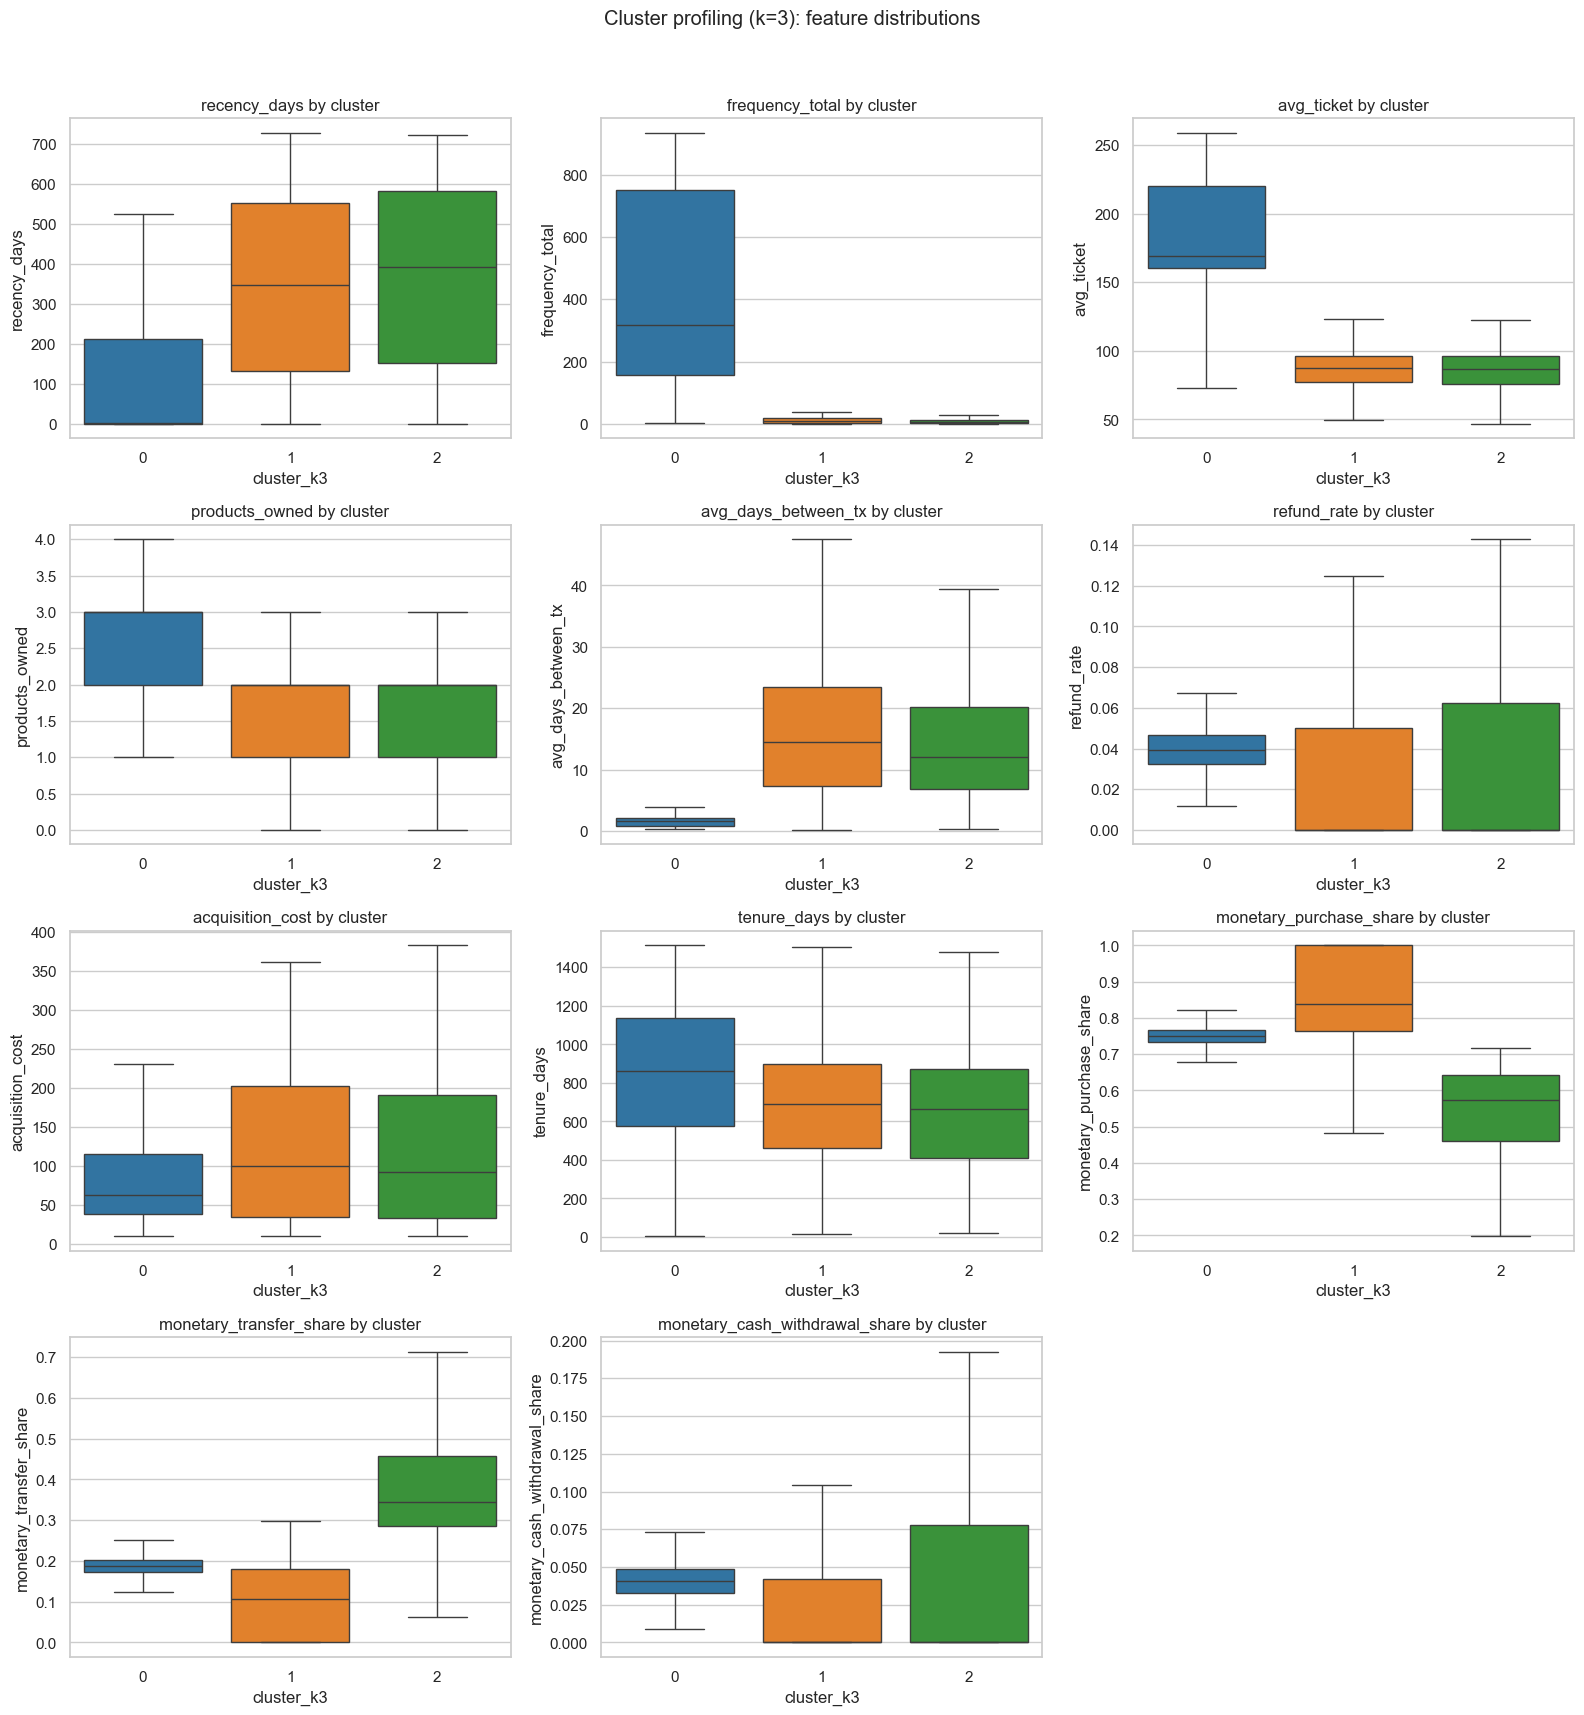

recency_days        frequency_total        avg_ticket          \
                   mean median            mean median       mean  median   
cluster_k3                                                                 
0                127.89    2.0          404.08  318.0     188.09  169.18   
1                349.17  347.0           12.27   10.0      87.65   87.58   
2                366.68  393.0            9.86    7.0      88.49   86.69   

           products_owned        avg_days_between_tx         ... tenure_days  \
                     mean median                mean median  ...        mean   
cluster_k3                                                   ...               
0                    2.57    3.0                1.55   1.69  ...      836.62   
1                    1.70    2.0               60.67  14.46  ...      689.90   
2                    1.75    2.0               43.24  12.05  ...      654.80   

                  monetary_purchase_share        monetary_transfer_share  \
           median                    mean median                    mean   
cluster_k3                                                                 
0           861.0                    0.75   0.75                    0.19   
1           691.0                    0.85   0.84                    0.10   
2           665.0                    0.52   0.57                    0.39   

                  monetary_cash_withdrawal_share        refund_rate         
           median                           mean median        mean median  
cluster_k3                                                                  
0            0.19                           0.04   0.04        0.04   0.04  
1            0.11                           0.03   0.00        0.03   0.00  
2            0.35                           0.07   0.00        0.04   0.00  

[3 rows x 22 columns]

In [63]:
from sklearn.decomposition import PCA

plot_df = df_clustering.copy()
plot_df["cluster_k3"] = labels_k3

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
plot_df["pc1"] = X_pca[:, 0]
plot_df["pc2"] = X_pca[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=plot_df,
    x="pc1",
    y="pc2",
    hue="cluster_k3",
    palette="tab10",
    alpha=0.55,
    s=22,
    linewidth=0,
)
plt.title(
    f"K-means clusters (k={k_fit}) on PCA projection | "
    f"explained variance: {(pca.explained_variance_ratio_.sum() * 100):.1f}%"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="cluster_k3")
plt.tight_layout()
plt.show()

feature_view = [
    c
    for c in [
        "recency_days",
        "frequency_total",
        "avg_ticket",
        "products_owned",
        "avg_days_between_tx",
        "refund_rate",
        "acquisition_cost",
        "tenure_days",
        "monetary_purchase_share",
        "monetary_transfer_share",
        "monetary_cash_withdrawal_share",
    ]
    if c in plot_df.columns
]

n_cols = 3
n_rows = int(np.ceil(len(feature_view) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(feature_view):
    sns.boxplot(
        data=plot_df,
        x="cluster_k3",
        y=col,
        hue="cluster_k3",
        ax=axes[i],
        palette="tab10",
        showfliers=False,
    )
    if axes[i].get_legend() is not None:
        axes[i].get_legend().remove()
    axes[i].set_title(f"{col} by cluster")
    axes[i].set_xlabel("cluster_k3")

for j in range(len(feature_view), len(axes)):
    axes[j].axis("off")

plt.suptitle(f"Cluster profiling (k={k_fit}): feature distributions", y=1.02)
plt.tight_layout()
plt.show()

profile_cols = [c for c in feature_view if c != "refund_rate"] + (
    ["refund_rate"] if "refund_rate" in feature_view else []
)
cluster_profile = (
    plot_df.groupby("cluster_k3", as_index=True)[profile_cols]
    .agg(["mean", "median"])
    .round(2)
)
display(cluster_profile)


### Cluster profiling — actionable read (k = 3)

**How to read this:** `cluster_k3` labels are **arbitrary integers** from k-means (0 / 1 / 2). What matters is the **behavioral profile** in `plot_df` (medians and spread in the charts above), not the digit. The narrative below matches a typical reading of **this** solution; after any refit, re-check medians before naming segments in production.

| Cluster | Working label (this run) | Core pattern | Directional actions |
|--------|---------------------------|--------------|---------------------|
| **0** | **Core engaged / high intensity** | Lower **recency**, higher **frequency**, higher **avg_ticket**, more **products_owned**, shorter **avg_days_between_tx**, longer **tenure**; **purchase-heavy** mix with meaningful transfer share. | **Retain & grow:** priority service, loyalty and cross-sell; use as benchmark cohort for experiments; protect from aggressive fee or limit changes without testing. |
| **1** | **Dormant, purchase-skewed** | Higher **recency**, very low **frequency**, moderate ticket; when they spend, **monetary_purchase_share** dominates; often **higher acquisition_cost** vs current activity. | **Reactivation:** win-back on **purchase** use cases (offers, merchant tie-ins); review **CAC vs realised engagement** for lookalikes; avoid scaling paid acquisition until reactivation shows payback. |
| **2** | **Dormant, transfer / cash–oriented** | Very high **recency**, low **frequency**; **higher monetary_transfer_share** and **monetary_cash_withdrawal_share**, lower **monetary_purchase_share**; **refund_rate** can show a heavier upper tail for some users. | **Use-case & risk:** explore whether behaviour reflects remittance / cash access vs underused purchase rails; monitor **refunds** and friction; test journeys that bridge **transfers → wallet purchases** where strategy fits; flag for collections / fraud review only when policy thresholds justify it. |

**Caveats:** Segments are **descriptive** (who looks alike today), not causal drivers of churn or LTV. Re-score after material changes to products, fees, or data definitions; watch **cluster size drift** and **median drift** quarter to quarter.


### Part 3 wrap-up

**What we locked in**

- **Feature space:** Part 2 ends with **`feature_cols`** including **RFM / behavioral numerics** plus **`monetary_purchase_share`**, **`monetary_transfer_share`**, and **`monetary_cash_withdrawal_share`**. In prior iterations this specification delivered the **strongest mean silhouette at `k=3`** among tested variants.
- **`k` choice:** **`k=3`** balances **silhouette evidence**, **silhouette blade diagnostics**, and **three-way** granularity suitable for differentiated CRM plays (not only “high vs low” at `k=2`).
- **Interpretation:** use **medians** (and dispersion) per cluster on **`plot_df`** — clusters are **descriptive** behavioural groups, not causal segments.

**Evolution and why we landed here**

- **Data & features:** Earlier iterations of the synthetic pipeline produced weak segment separation when activity was too uniform across customers; generation and validation were tightened so **dormancy** and **spend-mix** differences actually appear in the data (see cohort and RFM notebooks). On top of baseline RFM / behavioural numerics, we tested adding **transaction-type amount shares** (`monetary_*_share`). That specification became the **final** one: it adds orthogonal “**how** they use the wallet” signal on top of intensity, and in our runs it yielded the **strongest mean silhouette at the operational `k=3`** compared with the baseline-only feature set.
- **`k=3` vs max silhouette:** mean silhouette sometimes peaks at **`k=2`**, but we chose **`k=3`** so CRM can run **three differentiated** plays (core vs dormant purchase-skewed vs dormant transfer/cash–oriented) instead of a single high/low split.
- **Production framing:** the main analysis avoids tuning against **hidden labels** (no ARI/NMI in the core flow), matching how segmentation will be used when **true** segment labels do not exist.
- **Why `k` need not match `true_segment` cardinality:** The synthetic table plants **four** `true_segment` values, but **k-means** partitions customers in **feature space** (scaled RFM + behaviour + mix shares). That space is not the same as the label taxonomy: some planted types can overlap in the features we use, or separate along axes we did not engineer, so **the best `k` for CRM is not forced to equal four**. We pick **`k`** from internal diagnostics and interpretability, not from counting label types.
- **Analysis window vs “all” history:** Clustering uses **`df_tx` restricted to the notebook’s analysis window** (completed transactions with `transaction_datetime` in the defined range, and **`as_of_date`** pinned to the end of that window for RFM). We do **not** throw in the entire raw time span of the extract if it extends beyond that window, so recency and F/M stay **comparable** and we avoid blending obsolete behaviour with the period we care about for segmentation.

**What we deliberately did *not* do**

- No **ARI/NMI** or held-out “accuracy”: those require a **label** not available in production unsupervised deployment.
- **PCA** is shown only to **visualise** overlap; k-means was fit in **full scaled feature space**.

**Monitoring ideas (when this moves to production)**

- Track **cluster size drift** over time, **mean silhouette** on a scoring sample, and **centroid movement** in **`X_scaled`** space after periodic refits.
- Revisit **`k`** if the business needs more/fewer programmes — always reconcile with silhouette stability and profile interpretability.

**Future iterations — segmentation can improve**

This notebook locks a **k-means** baseline; it is not the only valid approach. Later iterations can improve separation, stability, or business fit by:

- **Other algorithms:** e.g. **Gaussian mixture models** (soft cluster membership, elliptical clusters), **agglomerative / hierarchical** clustering (nested segments), **density-based** methods (e.g. DBSCAN/HDBSCAN) when clusters are irregular or uneven in size, or **spectral** clustering when geometry is non-convex — each trades scalability and interpretability against k-means’ assumptions (roughly spherical groups in scaled space).
- **Richer inputs:** temporal or sequence features, cohort-style flags, optional **embeddings** from transaction history, or **semi-supervised** learning if partial labels or business rules become available.
- **Stronger evaluation:** bootstrap / temporal **stability**, overlap with downstream KPIs, and **A/B tests** on treatments — not only internal indices like silhouette.

Expect to **revisit** features, **`k`**, and algorithm choice as the product and customer base evolve.

---

**Next steps (roadmap):** export **`customer_id` → `cluster_k3`** for activation workflows; align CRM copy and journey rules with the **Cluster profiling — actionable read** section above; refresh labels when refitting the model.


In [68]:
# Experiment: add product monetary shares + encoded acquisition_channel, then rerun k-means
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.preprocessing import StandardScaler

# Keep same k as selected earlier (fallback to 3)
k_exp = int(k_selected) if "k_selected" in globals() else 3

# Baseline frame (same eligible population used in clustering)
df_base = df_clustering.copy()

# --- 1) Product-type monetary shares per customer (wallet / credit_card / investment)
prod_amount = (
    df_tx.groupby(["customer_id", "product_type"], as_index=False)["amount"]
    .sum()
    .pivot(index="customer_id", columns="product_type", values="amount")
    .fillna(0.0)
)

prod_total = prod_amount.sum(axis=1).replace(0, np.nan)
prod_share = prod_amount.div(prod_total, axis=0).fillna(0.0)

# Ensure required columns exist even if a product has zero rows in a run
for _pt in ["wallet", "credit_card", "investment"]:
    if _pt not in prod_share.columns:
        prod_share[_pt] = 0.0

prod_share = prod_share[["investment", "credit_card", "wallet"]].rename(
    columns={
        "investment": "investment_share_amount",
        "credit_card": "credit_card_share_amount",
        "wallet": "wallet_share_amount",
    }
)

# --- 2) Acquisition channel one-hot encoding
acq_ohe = pd.get_dummies(
    df_customers[["customer_id", "acquisition_channel"]].set_index("customer_id")["acquisition_channel"],
    prefix="acq",
    dtype=float,
)

# Build augmented feature frame for the same customers in df_clustering
aug_extra = prod_share.join(acq_ohe, how="outer").reset_index()
df_aug = df_base.merge(aug_extra, on="customer_id", how="left")

new_feature_cols = [
    "investment_share_amount",
    "credit_card_share_amount",
    "wallet_share_amount",
] + [c for c in df_aug.columns if c.startswith("acq_")]

for _col in new_feature_cols:
    if _col not in df_aug.columns:
        df_aug[_col] = 0.0
    df_aug[_col] = df_aug[_col].fillna(0.0).astype(float)

# Existing baseline feature columns from prior section
base_feature_cols = [c for c in feature_cols if c in df_base.columns]
aug_feature_cols = base_feature_cols + new_feature_cols

# --- 3) Compare baseline vs augmented with mixed preprocessing
# We keep two goals:
# (a) preserve the existing behavior-space setup;
# (b) avoid over-normalizing bounded one-hot/share signals.

# Baseline (scaled) for reference
scaler_base = StandardScaler()
X_base_scaled = scaler_base.fit_transform(df_base[base_feature_cols])

# Augmented fully scaled (reference)
scaler_aug = StandardScaler()
X_aug_scaled = scaler_aug.fit_transform(df_aug[aug_feature_cols])

# Augmented unscaled (reference)
X_aug_raw = df_aug[aug_feature_cols].to_numpy()

# Augmented mixed: scale only legacy/base cols, keep product shares + channel OHE unscaled
scaler_mixed_base = StandardScaler()
X_base_part_scaled = scaler_mixed_base.fit_transform(df_aug[base_feature_cols])
X_new_part_raw = df_aug[new_feature_cols].to_numpy()
X_aug_mixed = np.hstack([X_base_part_scaled, X_new_part_raw])

km_base = KMeans(n_clusters=k_exp, random_state=42, n_init=20)
km_aug_scaled = KMeans(n_clusters=k_exp, random_state=42, n_init=20)
km_aug_raw = KMeans(n_clusters=k_exp, random_state=42, n_init=20)
km_aug_mixed = KMeans(n_clusters=k_exp, random_state=42, n_init=20)

labels_base = km_base.fit_predict(X_base_scaled)
labels_aug_scaled = km_aug_scaled.fit_predict(X_aug_scaled)
labels_aug_raw = km_aug_raw.fit_predict(X_aug_raw)
labels_aug_mixed = km_aug_mixed.fit_predict(X_aug_mixed)

comparison = pd.DataFrame(
    [
        {
            "setup": "baseline_scaled",
            "n_features": len(base_feature_cols),
            "silhouette": silhouette_score(X_base_scaled, labels_base),
            "davies_bouldin": davies_bouldin_score(X_base_scaled, labels_base),
            "calinski_harabasz": calinski_harabasz_score(X_base_scaled, labels_base),
        },
        {
            "setup": "augmented_scaled",
            "n_features": len(aug_feature_cols),
            "silhouette": silhouette_score(X_aug_scaled, labels_aug_scaled),
            "davies_bouldin": davies_bouldin_score(X_aug_scaled, labels_aug_scaled),
            "calinski_harabasz": calinski_harabasz_score(X_aug_scaled, labels_aug_scaled),
        },
        {
            "setup": "augmented_unscaled",
            "n_features": len(aug_feature_cols),
            "silhouette": silhouette_score(X_aug_raw, labels_aug_raw),
            "davies_bouldin": davies_bouldin_score(X_aug_raw, labels_aug_raw),
            "calinski_harabasz": calinski_harabasz_score(X_aug_raw, labels_aug_raw),
        },
        {
            "setup": "augmented_mixed",
            "n_features": len(aug_feature_cols),
            "silhouette": silhouette_score(X_aug_mixed, labels_aug_mixed),
            "davies_bouldin": davies_bouldin_score(X_aug_mixed, labels_aug_mixed),
            "calinski_harabasz": calinski_harabasz_score(X_aug_mixed, labels_aug_mixed),
        },
    ]
)

comparison = comparison.sort_values("silhouette", ascending=False).reset_index(drop=True)

print(f"k used in experiment: {k_exp}")
print("\nAdded feature columns:")
print(new_feature_cols)
print("\nComparison (higher silhouette/CHI and lower DBI are better):")
display(comparison)

# Persist the best setup labels for downstream profiling in this notebook
best_setup = comparison.loc[0, "setup"]
label_map = {
    "baseline_scaled": labels_base,
    "augmented_scaled": labels_aug_scaled,
    "augmented_unscaled": labels_aug_raw,
    "augmented_mixed": labels_aug_mixed,
}

df_clustering_exp = df_aug.copy()
df_clustering_exp["cluster_k3_exp"] = label_map[best_setup]
print(f"\nSelected setup for df_clustering_exp: {best_setup}")


k used in experiment: 3

Added feature columns:
['investment_share_amount', 'credit_card_share_amount', 'wallet_share_amount', 'acq_organic', 'acq_paid_ads', 'acq_partnership', 'acq_referral']

Comparison (higher silhouette/CHI and lower DBI are better):


,setup,n_features,silhouette,davies_bouldin,calinski_harabasz
0,augmented_unscaled,19,0.413748,0.872158,4198.113161
1,baseline_scaled,12,0.175648,1.707146,762.473892
2,augmented_mixed,19,0.161833,1.803999,700.723962
3,augmented_scaled,19,0.132221,2.326185,617.749481



Selected setup for df_clustering_exp: augmented_unscaled


k used: 3
original scaled augmented features: 19
PCA components kept (80% variance): 10
Cumulative explained variance: 0.8230

Metrics on PCA-80 space:
silhouette: 0.167572
davies_bouldin: 2.047100
calinski_harabasz: 791.295204


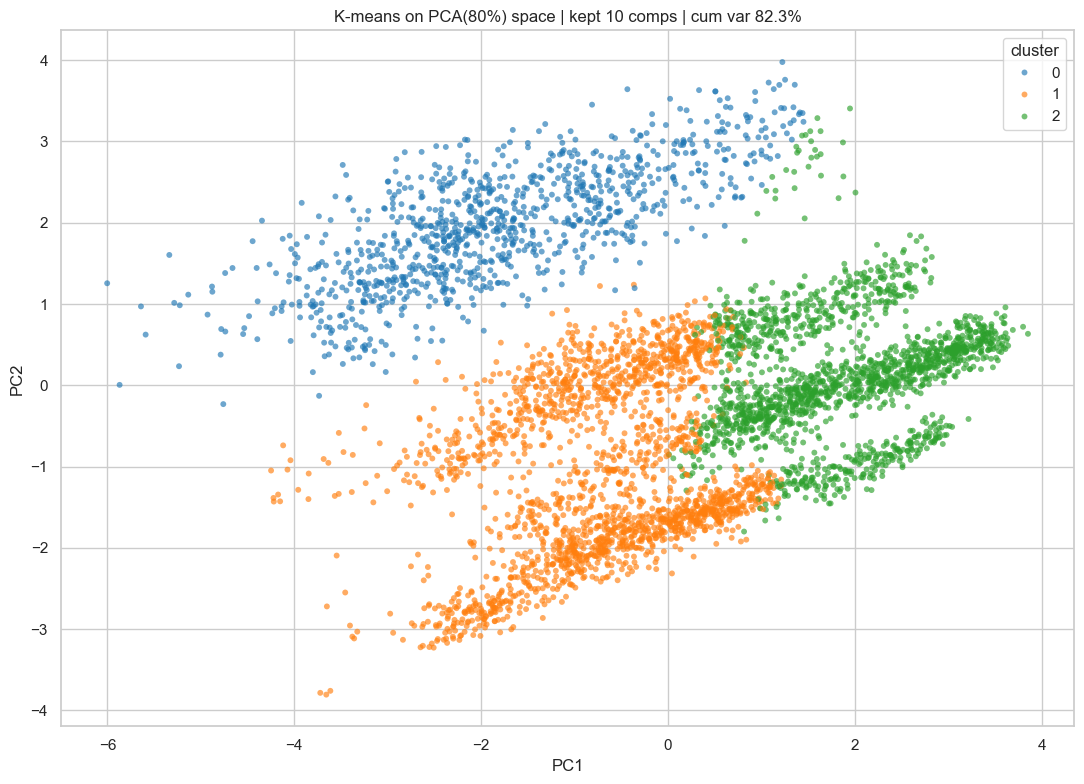

In [69]:
# Experiment: PCA (80% explained variance) after scaling on augmented features
from sklearn.decomposition import PCA

# Rebuild scaled augmented matrix to keep this cell self-contained
base_feature_cols = [c for c in feature_cols if c in df_clustering.columns]

prod_amount = (
    df_tx.groupby(["customer_id", "product_type"], as_index=False)["amount"]
    .sum()
    .pivot(index="customer_id", columns="product_type", values="amount")
    .fillna(0.0)
)
prod_total = prod_amount.sum(axis=1).replace(0, np.nan)
prod_share = prod_amount.div(prod_total, axis=0).fillna(0.0)

for _pt in ["wallet", "credit_card", "investment"]:
    if _pt not in prod_share.columns:
        prod_share[_pt] = 0.0

prod_share = prod_share[["investment", "credit_card", "wallet"]].rename(
    columns={
        "investment": "investment_share_amount",
        "credit_card": "credit_card_share_amount",
        "wallet": "wallet_share_amount",
    }
)

acq_ohe = pd.get_dummies(
    df_customers[["customer_id", "acquisition_channel"]].set_index("customer_id")["acquisition_channel"],
    prefix="acq",
    dtype=float,
)

df_aug = (
    df_clustering[["customer_id"] + base_feature_cols]
    .merge(prod_share.join(acq_ohe, how="outer").reset_index(), on="customer_id", how="left")
)

new_feature_cols = [
    "investment_share_amount",
    "credit_card_share_amount",
    "wallet_share_amount",
] + [c for c in df_aug.columns if c.startswith("acq_")]

for _col in new_feature_cols:
    if _col not in df_aug.columns:
        df_aug[_col] = 0.0
    df_aug[_col] = df_aug[_col].fillna(0.0).astype(float)

aug_feature_cols = base_feature_cols + new_feature_cols

scaler_aug = StandardScaler()
X_aug_scaled = scaler_aug.fit_transform(df_aug[aug_feature_cols])

# PCA to retain 80% cumulative explained variance
pca_80 = PCA(n_components=0.80, random_state=42)
X_pca_80 = pca_80.fit_transform(X_aug_scaled)

k_exp = int(k_selected) if "k_selected" in globals() else 3
km_pca_80 = KMeans(n_clusters=k_exp, random_state=42, n_init=20)
labels_pca_80 = km_pca_80.fit_predict(X_pca_80)

sil_pca_80 = silhouette_score(X_pca_80, labels_pca_80)
db_pca_80 = davies_bouldin_score(X_pca_80, labels_pca_80)
chi_pca_80 = calinski_harabasz_score(X_pca_80, labels_pca_80)

print(f"k used: {k_exp}")
print(f"original scaled augmented features: {X_aug_scaled.shape[1]}")
print(f"PCA components kept (80% variance): {X_pca_80.shape[1]}")
print(f"Cumulative explained variance: {pca_80.explained_variance_ratio_.sum():.4f}")
print("\nMetrics on PCA-80 space:")
print(f"silhouette: {sil_pca_80:.6f}")
print(f"davies_bouldin: {db_pca_80:.6f}")
print(f"calinski_harabasz: {chi_pca_80:.6f}")

# Optional quick visual (first two PCs only)
plot_df_pca = pd.DataFrame({
    "PC1": X_pca_80[:, 0],
    "PC2": X_pca_80[:, 1] if X_pca_80.shape[1] > 1 else np.zeros(X_pca_80.shape[0]),
    "cluster_k3_pca80": labels_pca_80,
})

plt.figure(figsize=(11, 8))
sns.scatterplot(
    data=plot_df_pca,
    x="PC1",
    y="PC2",
    hue="cluster_k3_pca80",
    palette="tab10",
    s=18,
    alpha=0.65,
    linewidth=0,
)
plt.title(
    f"K-means on PCA(80%) space | kept {X_pca_80.shape[1]} comps | "
    f"cum var {pca_80.explained_variance_ratio_.sum()*100:.1f}%"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="cluster")
plt.tight_layout()
plt.show()

# Save for optional downstream analysis
df_clustering_pca80 = df_aug.copy()
df_clustering_pca80["cluster_k3_pca80"] = labels_pca_80


,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,8.934557e+08,0.362324,1.117497,2977.675500
1,3,5.287877e+08,0.413748,0.872158,4198.113161
2,4,4.327006e+08,0.392460,0.971389,3780.764189
3,5,3.653584e+08,0.371412,0.978168,3582.361075
4,6,3.095080e+08,0.356827,0.943044,3558.381601
5,7,2.696729e+08,0.392239,0.831047,3522.714510
6,8,2.319646e+08,0.369547,0.872244,3622.831942


Suggested k by silhouette (winner setup): 3


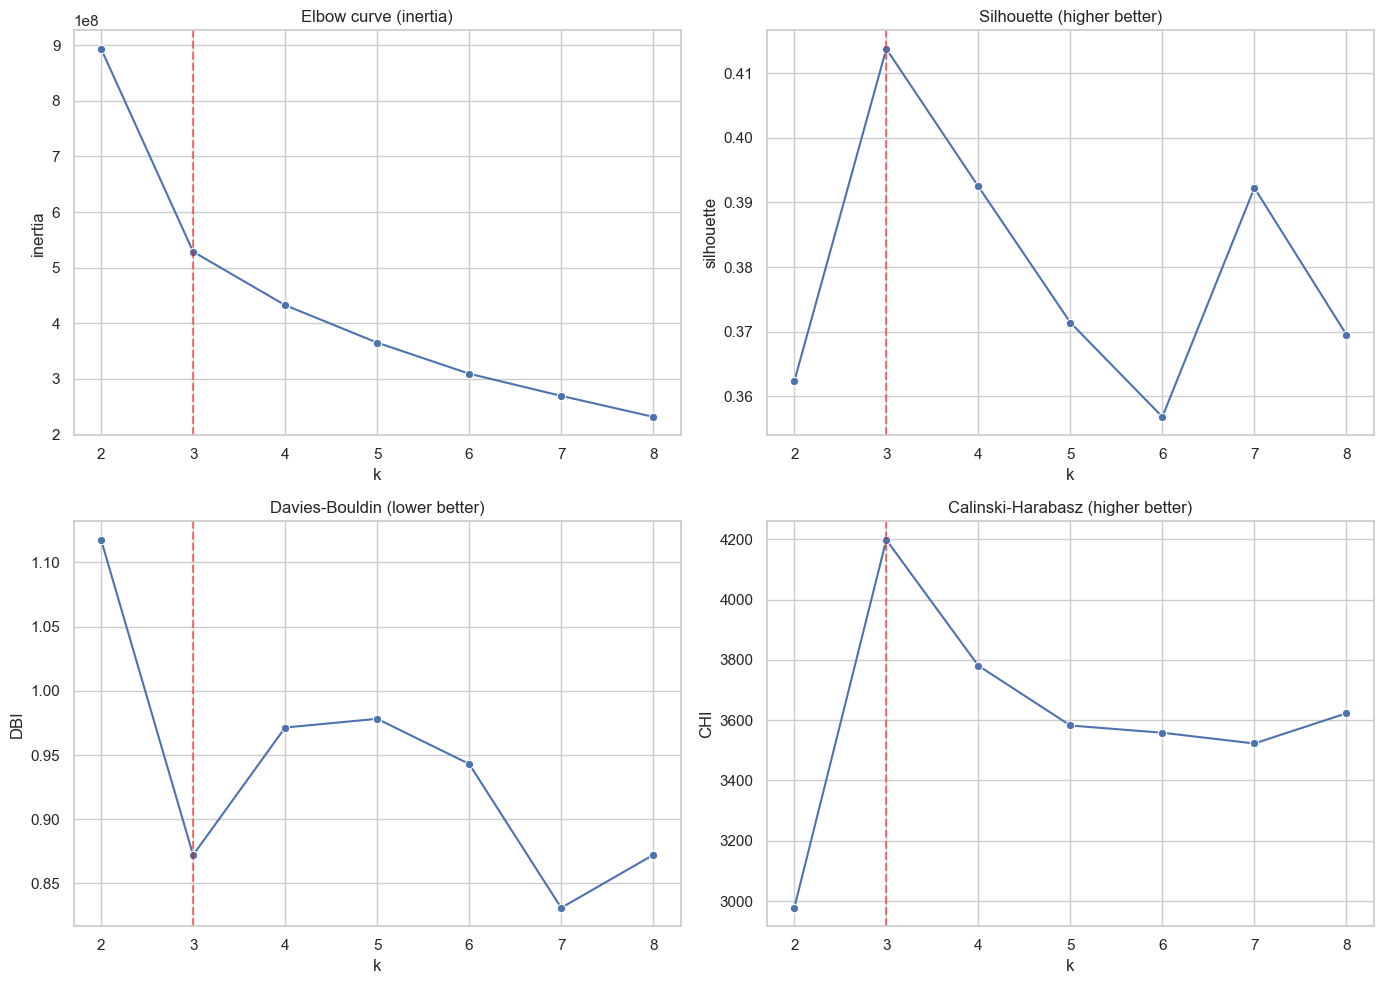

In [70]:
# Winner setup model-selection: choose k on augmented_unscaled feature space
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Rebuild winner feature matrix (self-contained): base clustering features + product shares + acquisition channel OHE
base_feature_cols = [c for c in feature_cols if c in df_clustering.columns]

prod_amount = (
    df_tx.groupby(["customer_id", "product_type"], as_index=False)["amount"]
    .sum()
    .pivot(index="customer_id", columns="product_type", values="amount")
    .fillna(0.0)
)
prod_total = prod_amount.sum(axis=1).replace(0, np.nan)
prod_share = prod_amount.div(prod_total, axis=0).fillna(0.0)

for _pt in ["wallet", "credit_card", "investment"]:
    if _pt not in prod_share.columns:
        prod_share[_pt] = 0.0

prod_share = prod_share[["investment", "credit_card", "wallet"]].rename(
    columns={
        "investment": "investment_share_amount",
        "credit_card": "credit_card_share_amount",
        "wallet": "wallet_share_amount",
    }
)

acq_ohe = pd.get_dummies(
    df_customers[["customer_id", "acquisition_channel"]].set_index("customer_id")["acquisition_channel"],
    prefix="acq",
    dtype=float,
)

df_winner = (
    df_clustering[["customer_id"] + base_feature_cols]
    .merge(prod_share.join(acq_ohe, how="outer").reset_index(), on="customer_id", how="left")
)

new_feature_cols = [
    "investment_share_amount",
    "credit_card_share_amount",
    "wallet_share_amount",
] + [c for c in df_winner.columns if c.startswith("acq_")]

for _col in new_feature_cols:
    if _col not in df_winner.columns:
        df_winner[_col] = 0.0
    df_winner[_col] = df_winner[_col].fillna(0.0).astype(float)

winner_feature_cols = base_feature_cols + new_feature_cols
X_winner = df_winner[winner_feature_cols].to_numpy()  # intentionally unscaled

# Evaluate candidate k values
k_values = list(range(2, 9))
rows = []
for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_winner)
    rows.append(
        {
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X_winner, labels),
            "davies_bouldin": davies_bouldin_score(X_winner, labels),
            "calinski_harabasz": calinski_harabasz_score(X_winner, labels),
        }
    )

k_eval = pd.DataFrame(rows)
display(k_eval)

# Suggested k (best silhouette as primary criterion)
k_best = int(k_eval.sort_values("silhouette", ascending=False).iloc[0]["k"])
print(f"Suggested k by silhouette (winner setup): {k_best}")

# Plot diagnostics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.lineplot(data=k_eval, x="k", y="inertia", marker="o", ax=axes[0, 0])
axes[0, 0].set_title("Elbow curve (inertia)")
axes[0, 0].set_xlabel("k")
axes[0, 0].set_ylabel("inertia")

sns.lineplot(data=k_eval, x="k", y="silhouette", marker="o", ax=axes[0, 1])
axes[0, 1].set_title("Silhouette (higher better)")
axes[0, 1].set_xlabel("k")
axes[0, 1].set_ylabel("silhouette")

sns.lineplot(data=k_eval, x="k", y="davies_bouldin", marker="o", ax=axes[1, 0])
axes[1, 0].set_title("Davies-Bouldin (lower better)")
axes[1, 0].set_xlabel("k")
axes[1, 0].set_ylabel("DBI")

sns.lineplot(data=k_eval, x="k", y="calinski_harabasz", marker="o", ax=axes[1, 1])
axes[1, 1].set_title("Calinski-Harabasz (higher better)")
axes[1, 1].set_xlabel("k")
axes[1, 1].set_ylabel("CHI")

for ax in axes.ravel():
    ax.axvline(k_best, color="red", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Fit final model at suggested k for immediate profiling use
km_winner_bestk = KMeans(n_clusters=k_best, random_state=42, n_init=20)
labels_winner_bestk = km_winner_bestk.fit_predict(X_winner)

df_clustering_winner = df_winner.copy()
df_clustering_winner[f"cluster_winner_k{k_best}"] = labels_winner_bestk


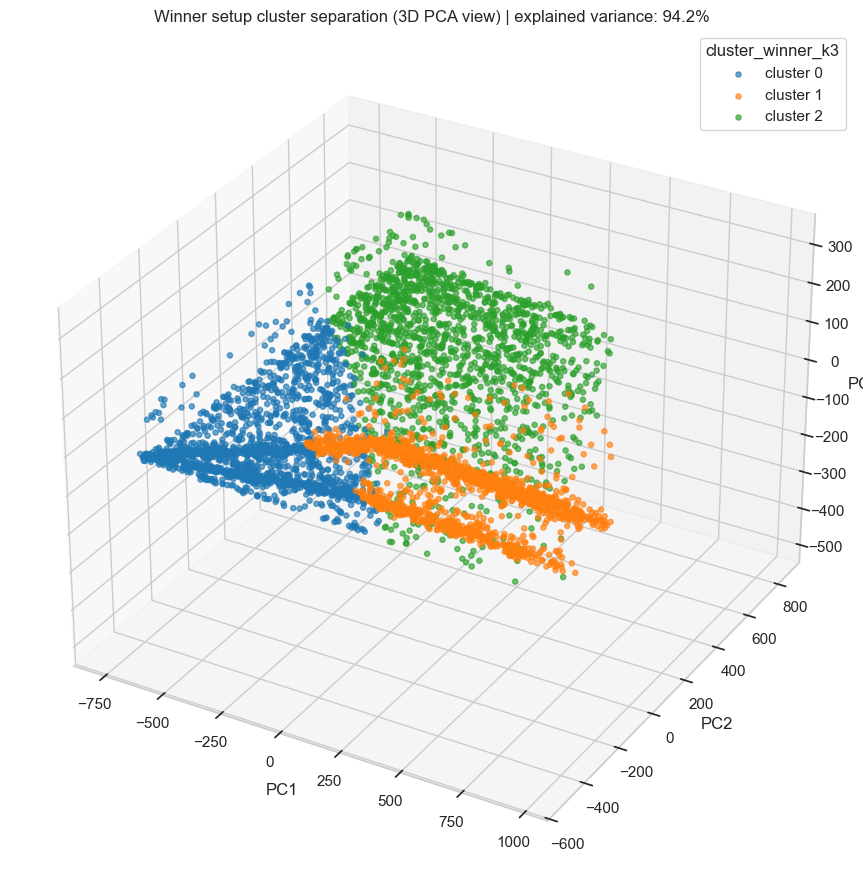

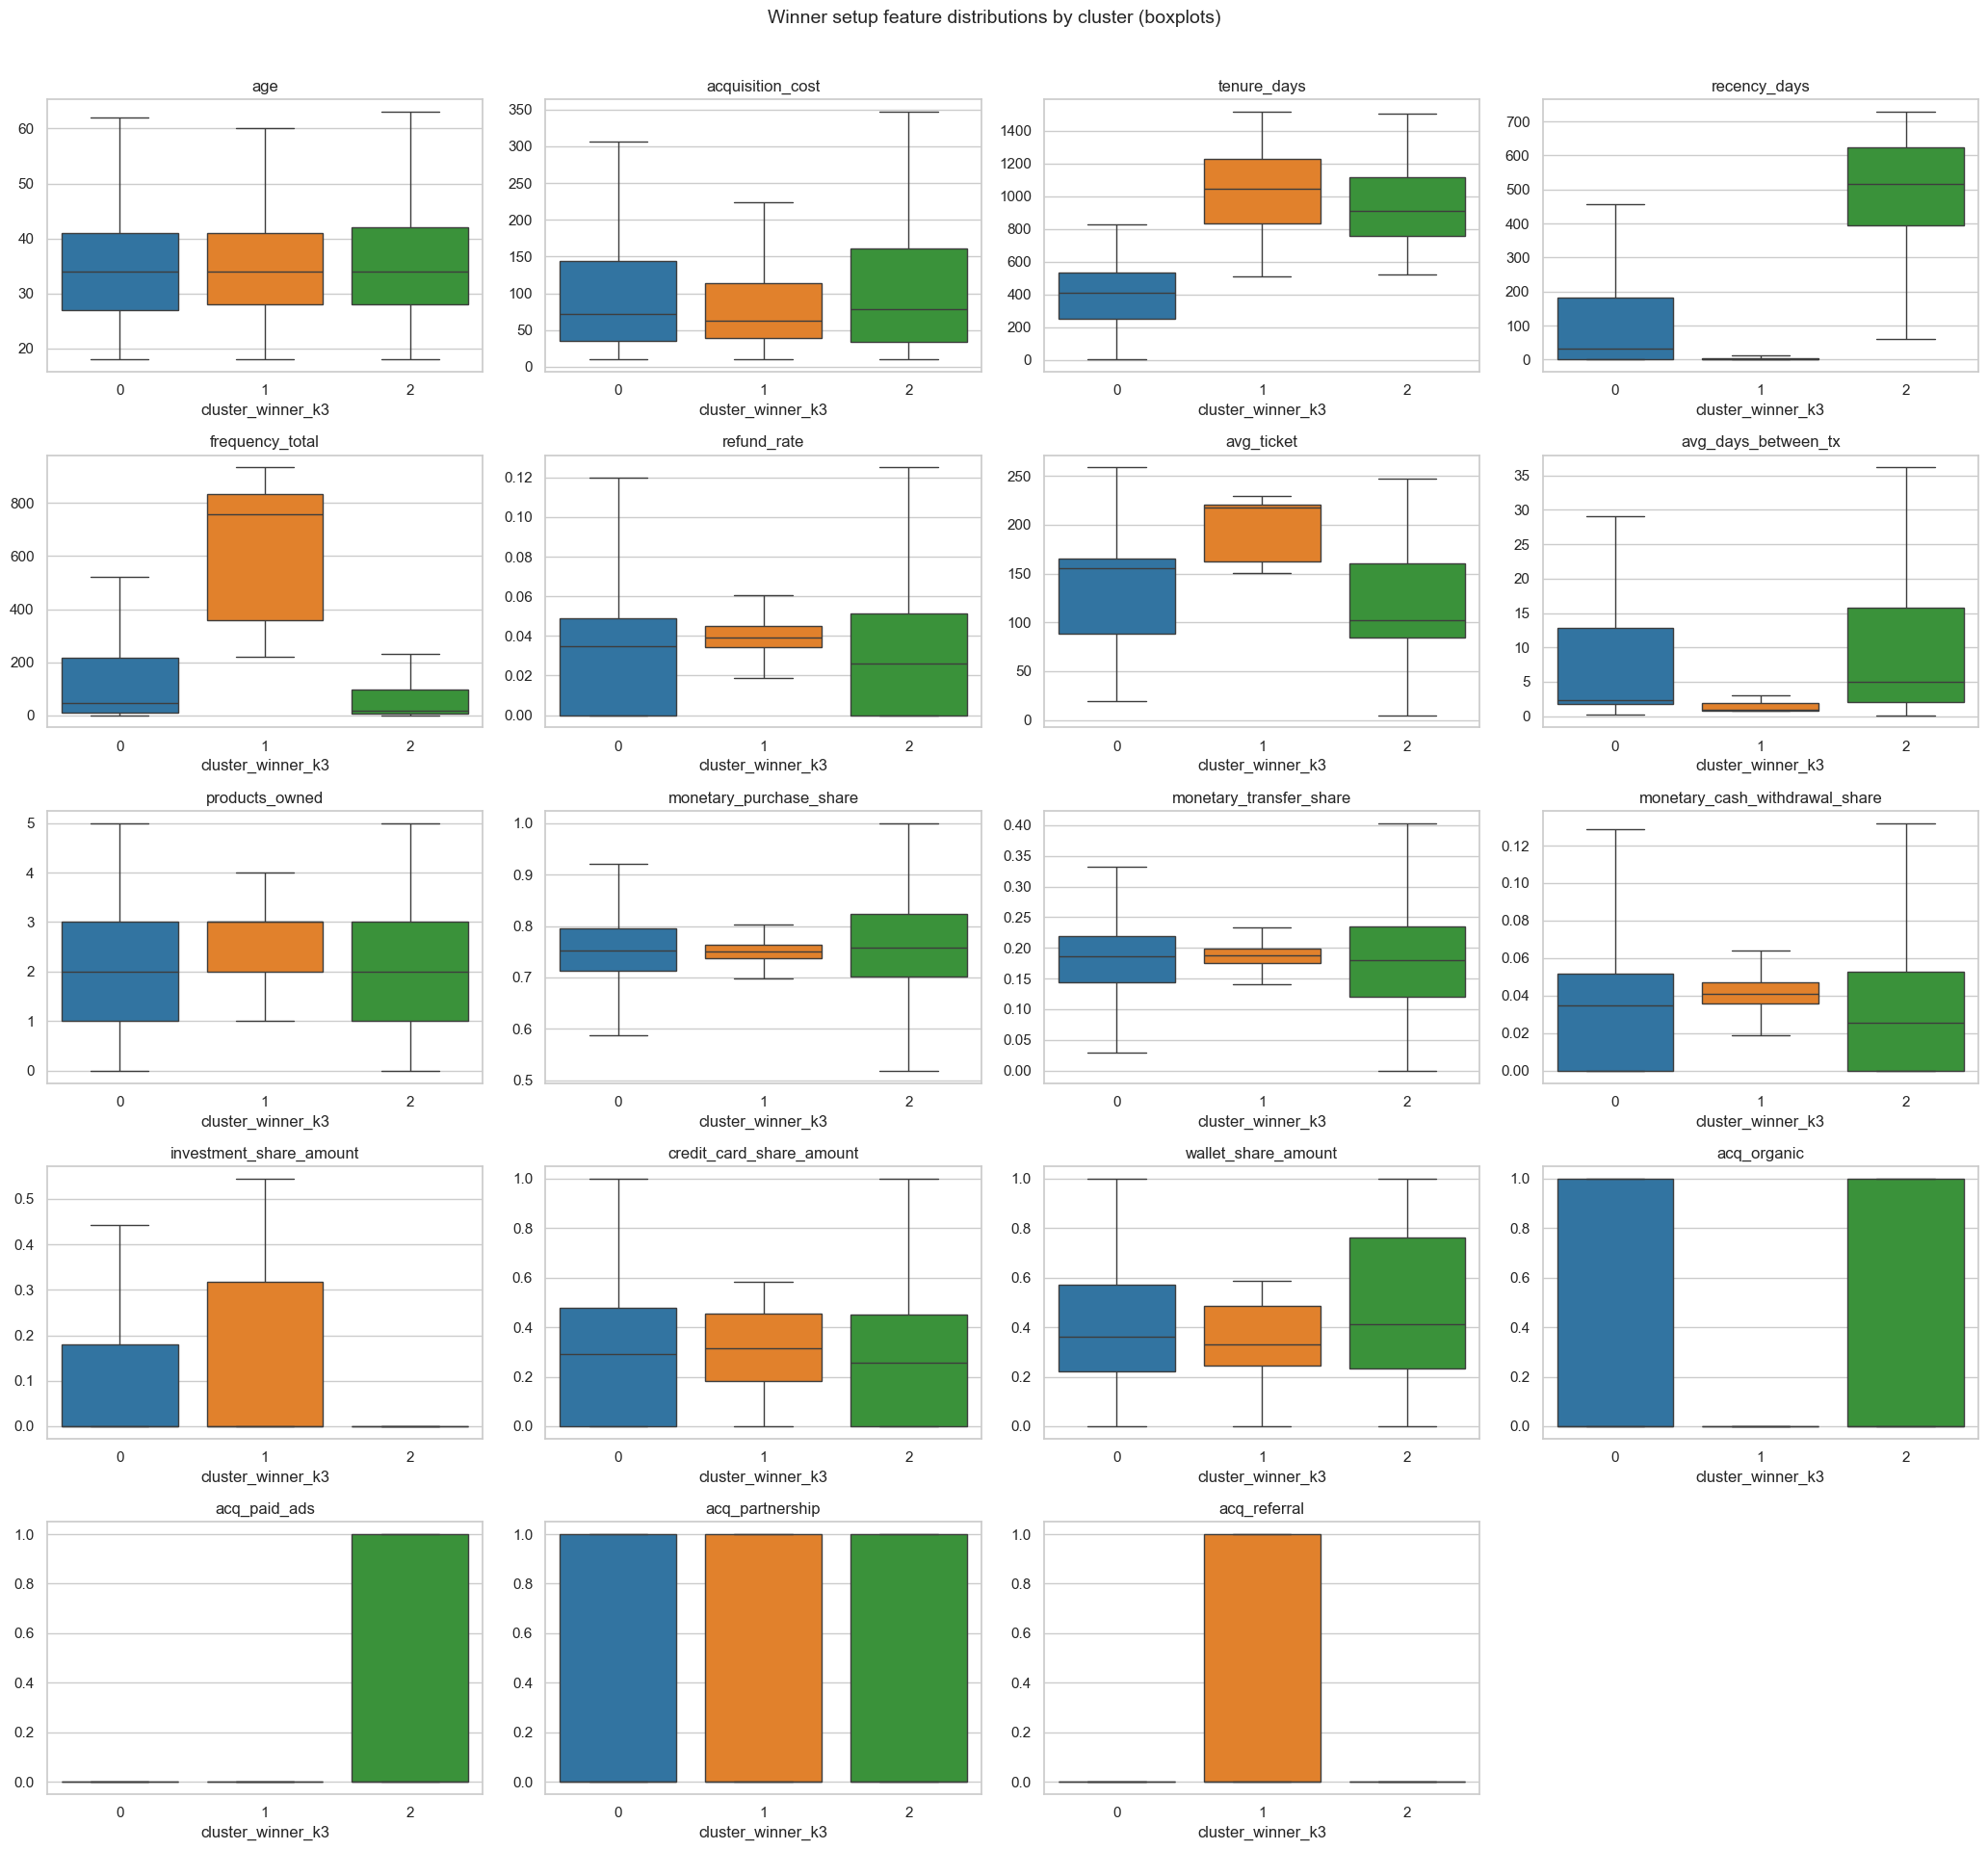

In [71]:
# Visual diagnostics (winner setup, k=3): 3D separation + feature boxplots
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

# Resolve winner frame / cluster column
if "df_clustering_winner" not in globals():
    raise ValueError("Run the winner k-selection cell first to create df_clustering_winner.")

cluster_candidates = [c for c in df_clustering_winner.columns if c.startswith("cluster_winner_k")]
if not cluster_candidates:
    raise ValueError("No cluster_winner_k* column found in df_clustering_winner.")

cluster_col = "cluster_winner_k3" if "cluster_winner_k3" in cluster_candidates else cluster_candidates[0]

# Feature columns from winner setup
if "winner_feature_cols" in globals():
    plot_feature_cols = winner_feature_cols
else:
    # Fallback: infer numeric features used in winner frame (excluding id and cluster labels)
    excluded = {"customer_id", cluster_col}
    excluded.update([c for c in df_clustering_winner.columns if c.startswith("cluster_")])
    plot_feature_cols = [
        c
        for c in df_clustering_winner.columns
        if c not in excluded and pd.api.types.is_numeric_dtype(df_clustering_winner[c])
    ]

# --- 1) 3D separation plot (PCA 3D projection for visualization)
X_winner_vis = df_clustering_winner[plot_feature_cols].to_numpy()
labels_vis = df_clustering_winner[cluster_col].to_numpy()

pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X_winner_vis)
exp3 = pca3.explained_variance_ratio_.sum() * 100

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

palette = sns.color_palette("tab10", n_colors=len(np.unique(labels_vis)))
for i, cluster_id in enumerate(sorted(np.unique(labels_vis))):
    m = labels_vis == cluster_id
    ax.scatter(
        X_3d[m, 0],
        X_3d[m, 1],
        X_3d[m, 2],
        s=14,
        alpha=0.65,
        color=palette[i],
        label=f"cluster {cluster_id}",
    )

ax.set_title(f"Winner setup cluster separation (3D PCA view) | explained variance: {exp3:.1f}%")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(title=cluster_col)
plt.tight_layout()
plt.show()

# --- 2) Boxplots for all winner features by cluster
n_features = len(plot_feature_cols)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.8 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for i, col in enumerate(plot_feature_cols):
    sns.boxplot(
        data=df_clustering_winner,
        x=cluster_col,
        y=col,
        hue=cluster_col,
        dodge=False,
        ax=axes_flat[i],
        palette="tab10",
        legend=False,
        showfliers=False,
    )
    axes_flat[i].set_title(col)
    axes_flat[i].set_xlabel(cluster_col)
    axes_flat[i].set_ylabel("")

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")

plt.suptitle("Winner setup feature distributions by cluster (boxplots)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


In [72]:
# Feature ablation on winner setup (k=3): try cleaner subsets
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

if "df_clustering_winner" not in globals():
    raise ValueError("Run the winner k-selection cell first (it creates df_clustering_winner).")

# Pick cluster count fixed at 3 (as selected)
k_ablation = 3

# Resolve feature list from winner setup
if "winner_feature_cols" in globals():
    base_cols_all = winner_feature_cols.copy()
else:
    excluded = {"customer_id"}
    excluded.update([c for c in df_clustering_winner.columns if c.startswith("cluster_")])
    base_cols_all = [
        c
        for c in df_clustering_winner.columns
        if c not in excluded and pd.api.types.is_numeric_dtype(df_clustering_winner[c])
    ]

all_channel_ohe = [c for c in base_cols_all if c.startswith("acq_")]
product_share_cols = [
    c
    for c in ["investment_share_amount", "credit_card_share_amount", "wallet_share_amount"]
    if c in base_cols_all
]
legacy_monetary_share_cols = [
    c
    for c in ["monetary_purchase_share", "monetary_transfer_share", "monetary_cash_withdrawal_share"]
    if c in base_cols_all
]

# Build candidate feature sets
candidates = {
    "A_current_winner": base_cols_all,
    "B_drop_acq_cost_keep_ohe": [c for c in base_cols_all if c != "acquisition_cost"],
    "C_drop_ohe_keep_acq_cost": [c for c in base_cols_all if c not in all_channel_ohe],
    "D_drop_acq_cost_and_ohe": [c for c in base_cols_all if c != "acquisition_cost" and c not in all_channel_ohe],
    # compositional redundancy: drop one product-share column (wallet)
    "E_drop_wallet_share": [c for c in base_cols_all if c != "wallet_share_amount"],
    # reduce duplication between two share families
    "F_drop_legacy_monetary_shares": [c for c in base_cols_all if c not in legacy_monetary_share_cols],
    # stronger pruning around channel + duplicate shares
    "G_no_acq_cost_no_wallet_no_legacy_shares": [
        c
        for c in base_cols_all
        if c != "acquisition_cost"
        and c != "wallet_share_amount"
        and c not in legacy_monetary_share_cols
    ],
}

rows = []
for name, cols in candidates.items():
    # Remove zero-variance columns for a fair run
    X_df = df_clustering_winner[cols].copy()
    nzv_cols = [c for c in X_df.columns if X_df[c].nunique(dropna=False) > 1]
    X = X_df[nzv_cols].to_numpy()

    km = KMeans(n_clusters=k_ablation, random_state=42, n_init=20)
    labels = km.fit_predict(X)

    rows.append(
        {
            "setup": name,
            "n_features_used": X.shape[1],
            "silhouette": silhouette_score(X, labels),
            "davies_bouldin": davies_bouldin_score(X, labels),
            "calinski_harabasz": calinski_harabasz_score(X, labels),
        }
    )

ablation_results = pd.DataFrame(rows)
ablation_results = ablation_results.sort_values("silhouette", ascending=False).reset_index(drop=True)

display(ablation_results)

best_ablation_setup = ablation_results.loc[0, "setup"]
best_cols_raw = candidates[best_ablation_setup]
best_cols = [c for c in best_cols_raw if df_clustering_winner[c].nunique(dropna=False) > 1]

print(f"Best ablation setup: {best_ablation_setup}")
print(f"Columns used ({len(best_cols)}):")
print(best_cols)

# Persist best-ablation clustering labels for optional next plots
km_best_ablation = KMeans(n_clusters=k_ablation, random_state=42, n_init=20)
labels_best_ablation = km_best_ablation.fit_predict(df_clustering_winner[best_cols].to_numpy())

df_clustering_ablation = df_clustering_winner.copy()
df_clustering_ablation["cluster_ablation_k3"] = labels_best_ablation


,setup,n_features_used,silhouette,davies_bouldin,calinski_harabasz
0,D_drop_acq_cost_and_ohe,14,0.430358,0.835812,4456.934068
1,G_no_acq_cost_no_wallet_no_legacy_shares,14,0.430356,0.835816,4456.907806
2,B_drop_acq_cost_keep_ohe,18,0.430355,0.835816,4456.902208
3,C_drop_ohe_keep_acq_cost,15,0.413750,0.872154,4198.141399
4,E_drop_wallet_share,18,0.413748,0.872158,4198.116862
5,F_drop_legacy_monetary_shares,16,0.413748,0.872158,4198.114421
6,A_current_winner,19,0.413748,0.872158,4198.113161


Best ablation setup: D_drop_acq_cost_and_ohe
Columns used (14):
['age', 'tenure_days', 'recency_days', 'frequency_total', 'refund_rate', 'avg_ticket', 'avg_days_between_tx', 'products_owned', 'monetary_purchase_share', 'monetary_transfer_share', 'monetary_cash_withdrawal_share', 'investment_share_amount', 'credit_card_share_amount', 'wallet_share_amount']


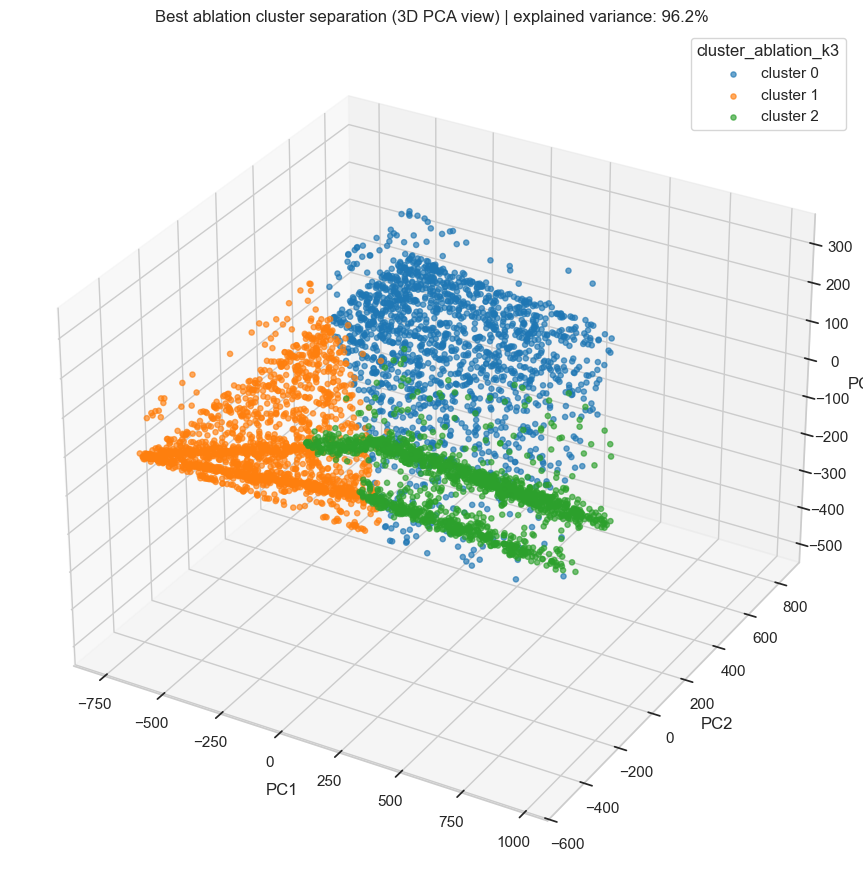

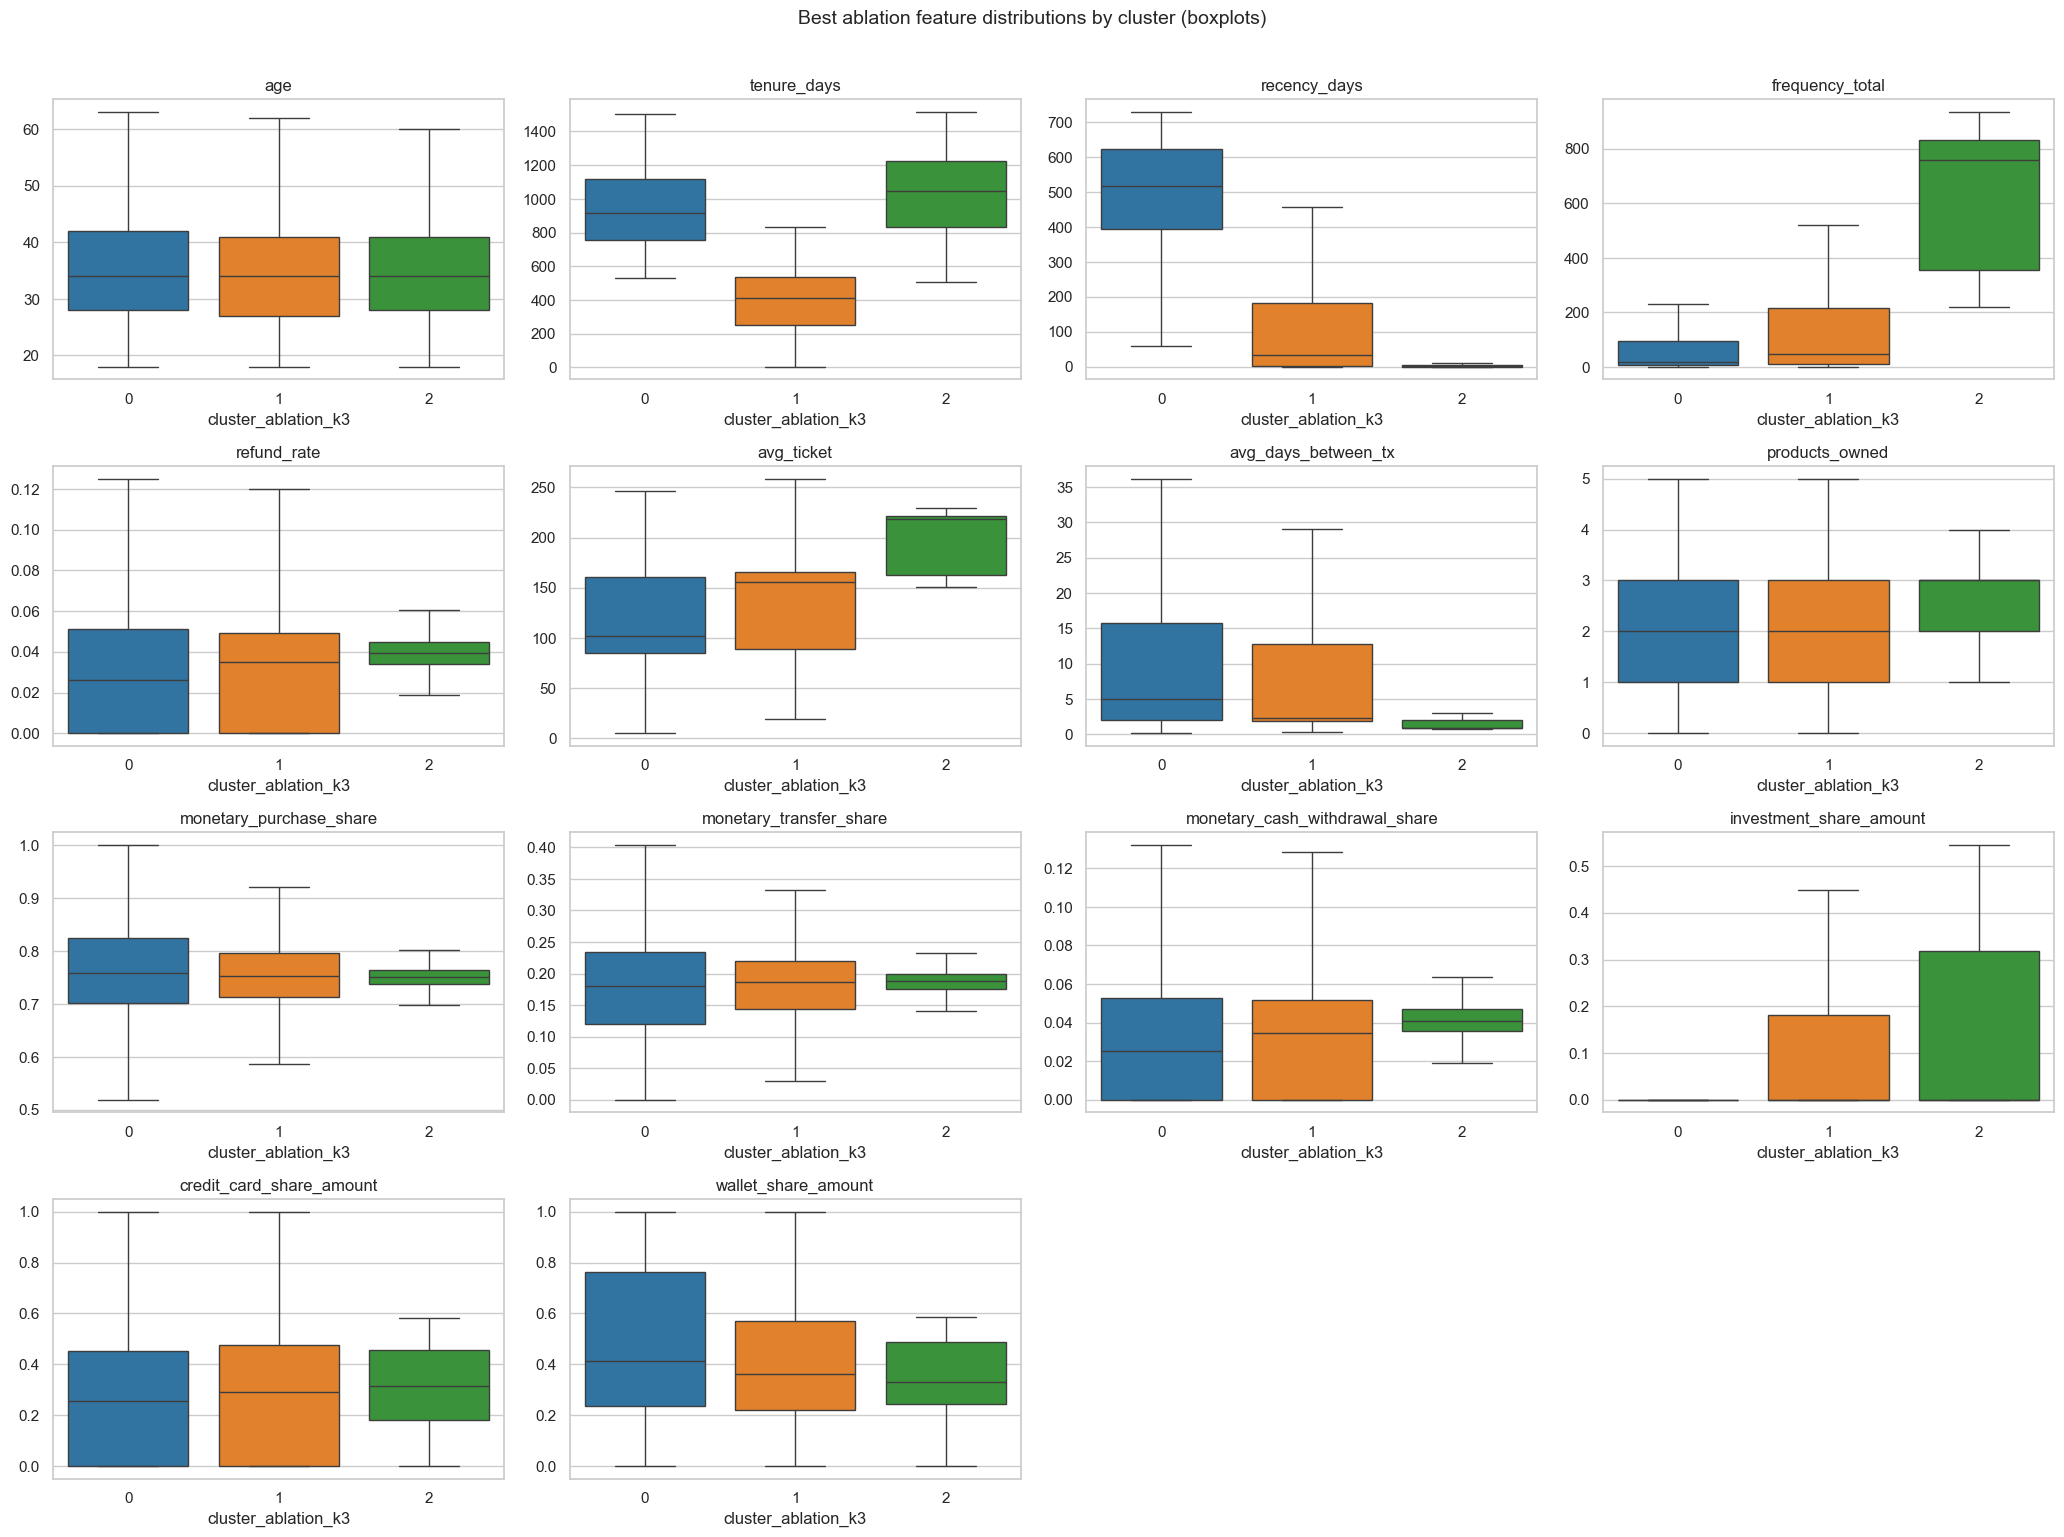

In [73]:
# Visualize best ablation winner: 3D clusters + boxplots (D_drop_acq_cost_and_ohe)
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.decomposition import PCA

if "df_clustering_ablation" not in globals():
    raise ValueError("Run the ablation cell first to create df_clustering_ablation.")
if "best_cols" not in globals():
    raise ValueError("Run the ablation cell first to define best_cols.")
if "cluster_ablation_k3" not in df_clustering_ablation.columns:
    raise ValueError("cluster_ablation_k3 not found. Re-run the ablation cell.")

cluster_col = "cluster_ablation_k3"
X_best = df_clustering_ablation[best_cols].to_numpy()
labels_best = df_clustering_ablation[cluster_col].to_numpy()

# --- 1) 3D PCA scatter for separation diagnostics
pca3 = PCA(n_components=3, random_state=42)
X_3d = pca3.fit_transform(X_best)
exp3 = pca3.explained_variance_ratio_.sum() * 100

fig = plt.figure(figsize=(11, 9))
ax = fig.add_subplot(111, projection="3d")

palette = sns.color_palette("tab10", n_colors=len(np.unique(labels_best)))
for i, cid in enumerate(sorted(np.unique(labels_best))):
    m = labels_best == cid
    ax.scatter(
        X_3d[m, 0],
        X_3d[m, 1],
        X_3d[m, 2],
        s=14,
        alpha=0.65,
        color=palette[i],
        label=f"cluster {cid}",
    )

ax.set_title(
    "Best ablation cluster separation (3D PCA view) | "
    f"explained variance: {exp3:.1f}%"
)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend(title=cluster_col)
plt.tight_layout()
plt.show()

# --- 2) Boxplots for selected best columns
n_features = len(best_cols)
n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.2 * n_cols, 3.8 * n_rows), squeeze=False)
axes_flat = axes.ravel()

for i, col in enumerate(best_cols):
    sns.boxplot(
        data=df_clustering_ablation,
        x=cluster_col,
        y=col,
        hue=cluster_col,
        dodge=False,
        ax=axes_flat[i],
        palette="tab10",
        legend=False,
        showfliers=False,
    )
    axes_flat[i].set_title(col)
    axes_flat[i].set_xlabel(cluster_col)
    axes_flat[i].set_ylabel("")

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].axis("off")

plt.suptitle("Best ablation feature distributions by cluster (boxplots)", y=1.01, fontsize=14)
plt.tight_layout()
plt.show()


Acquisition channel distribution within cluster (%):


acquisition_channel,organic,paid_ads,partnership,referral
cluster_k3,,,,
0,22.25,14.55,26.62,36.58
1,29.09,35.29,22.56,13.06
2,29.83,31.14,24.95,14.07


Acquisition channel lift vs overall (1.0 = average representation):


acquisition_channel,organic,paid_ads,partnership,referral
cluster_k3,,,,
0,0.90,0.68,1.05,1.29
1,1.17,1.64,0.89,0.46
2,1.20,1.45,0.98,0.50


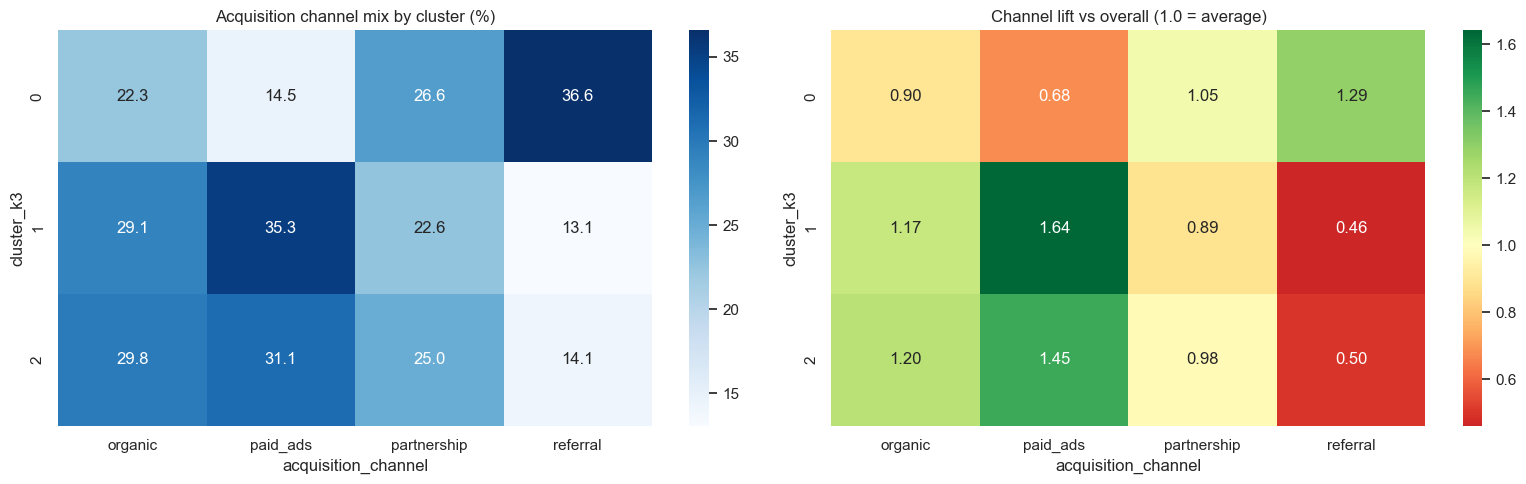

Product penetration by cluster (% customers owning active product):


product_type,credit_card,insurance,investment,loan,wallet
cluster_k3,,,,,
0,75.01,29.74,41.55,28.94,81.85
1,50.33,14.13,11.98,18.51,75.54
2,50.47,17.45,13.32,20.08,73.55


Product activity by cluster (% customers with >=1 tx in product):


product_type,credit_card,insurance,investment,loan,wallet
cluster_k3,,,,,
0,75.01,29.70,41.55,28.94,83.19
1,46.78,12.81,11.16,17.11,79.01
2,47.09,16.14,12.20,18.20,76.74


Gap = penetration - activity (pp): positive means under-activation among owners


product_type,credit_card,insurance,investment,loan,wallet
cluster_k3,,,,,
0,0.00,0.03,0.00,0.00,-1.34
1,3.55,1.32,0.83,1.40,-3.47
2,3.38,1.31,1.13,1.88,-3.19


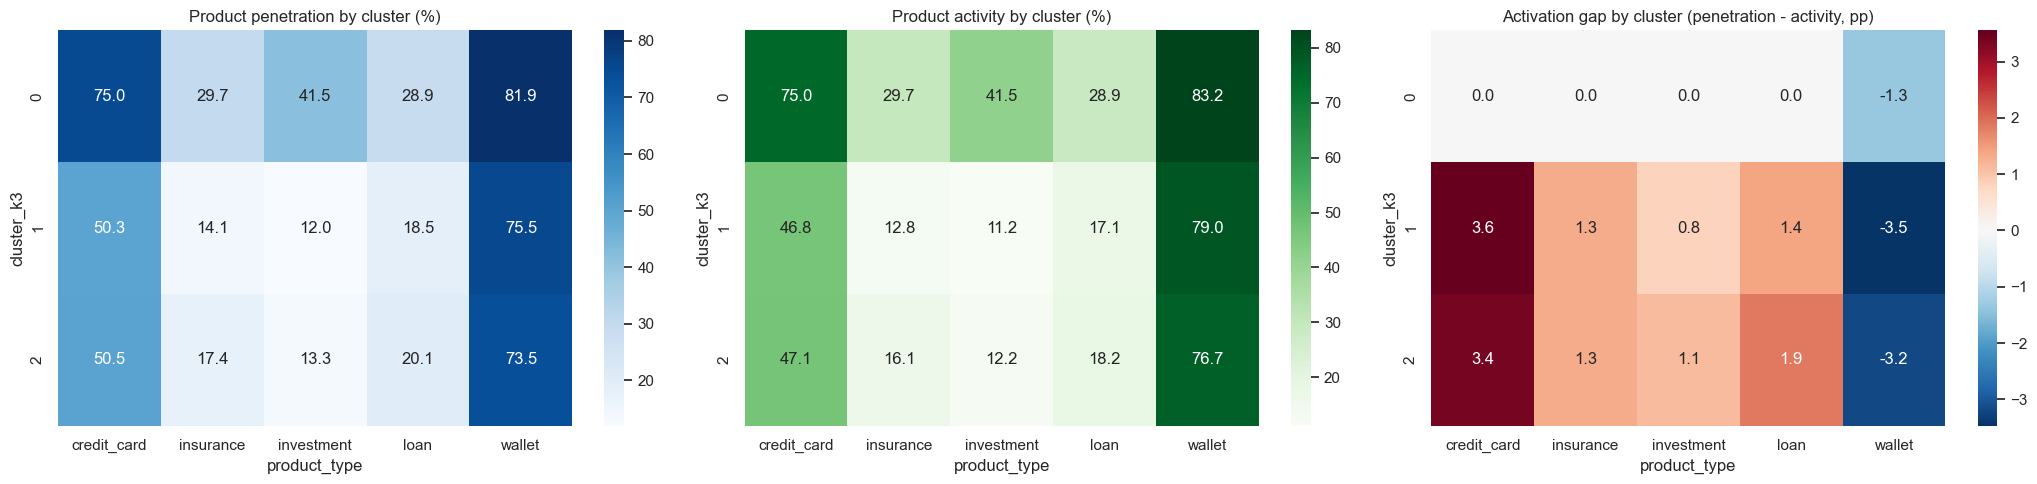

In [75]:
# Standard clusters (k=3) business read: acquisition channel + product penetration/activity gap

# 0) Resolve standard cluster assignment (pre one-hot/product-share experiments)
if "df_clustering" not in globals():
    raise ValueError("df_clustering not found. Run Part 3 (standard k=3 clustering) first.")

if "cluster_k3" not in df_clustering.columns:
    if "labels_k3" in globals() and len(labels_k3) == len(df_clustering):
        df_clustering = df_clustering.copy()
        df_clustering["cluster_k3"] = labels_k3
    else:
        raise ValueError("cluster_k3 not found in df_clustering and labels_k3 is unavailable.")

cluster_map = df_clustering[["customer_id", "cluster_k3"]].copy()

# 1) Acquisition channel distribution by cluster
cluster_channel = (
    cluster_map.merge(
        df_customers[["customer_id", "acquisition_channel"]],
        on="customer_id",
        how="left",
    )
)

channel_dist = pd.crosstab(
    cluster_channel["cluster_k3"],
    cluster_channel["acquisition_channel"],
    normalize="index",
).mul(100)

overall_channel = (
    cluster_channel["acquisition_channel"].value_counts(normalize=True).sort_index().mul(100)
)
channel_lift = channel_dist.copy()
for col in channel_lift.columns:
    channel_lift[col] = channel_lift[col] / overall_channel[col]

print("Acquisition channel distribution within cluster (%):")
display(channel_dist.round(2))
print("Acquisition channel lift vs overall (1.0 = average representation):")
display(channel_lift.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(channel_dist, annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
axes[0].set_title("Acquisition channel mix by cluster (%)")
axes[0].set_xlabel("acquisition_channel")
axes[0].set_ylabel("cluster_k3")

sns.heatmap(channel_lift, annot=True, fmt=".2f", cmap="RdYlGn", center=1.0, ax=axes[1])
axes[1].set_title("Channel lift vs overall (1.0 = average)")
axes[1].set_xlabel("acquisition_channel")
axes[1].set_ylabel("cluster_k3")
plt.tight_layout()
plt.show()

# 2) Product penetration (ownership) by cluster
cp_active = df_customer_products.copy()
if "is_active" in cp_active.columns:
    cp_active = cp_active[cp_active["is_active"] == True].copy()

cp_prod = cp_active.merge(df_products[["product_id", "product_type"]], on="product_id", how="left")
own_pairs = cp_prod[["customer_id", "product_type"]].dropna().drop_duplicates()

# Build full customer x product grid to keep the denominator correct.
# Without this grid, rates are inflated because only observed pairs are averaged.
all_product_types = sorted(df_products["product_type"].dropna().unique().tolist())
customer_product_base = (
    cluster_map.assign(_k=1)
    .merge(pd.DataFrame({"product_type": all_product_types, "_k": 1}), on="_k", how="left")
    .drop(columns="_k")
)

owner_flags = customer_product_base.merge(
    own_pairs.assign(owner_flag=1),
    on=["customer_id", "product_type"],
    how="left",
)
owner_flags["owner_flag"] = owner_flags["owner_flag"].fillna(0)

penetration = (
    owner_flags.groupby(["cluster_k3", "product_type"], as_index=False)["owner_flag"]
    .mean()
    .rename(columns={"owner_flag": "penetration_rate"})
)
penetration["penetration_rate"] *= 100

# 3) Product activity by cluster (has >=1 tx in product_type)
activity_pairs = df_tx[["customer_id", "product_type"]].dropna().drop_duplicates()
activity_flags = customer_product_base.merge(
    activity_pairs.assign(active_flag=1),
    on=["customer_id", "product_type"],
    how="left",
)
activity_flags["active_flag"] = activity_flags["active_flag"].fillna(0)

activity = (
    activity_flags.groupby(["cluster_k3", "product_type"], as_index=False)["active_flag"]
    .mean()
    .rename(columns={"active_flag": "activity_rate"})
)
activity["activity_rate"] *= 100

# 4) Gap table (penetration - activity)
prod_gap = penetration.merge(activity, on=["cluster_k3", "product_type"], how="outer").fillna(0.0)
prod_gap["gap_pen_minus_act"] = prod_gap["penetration_rate"] - prod_gap["activity_rate"]

gap_pivot = prod_gap.pivot(index="cluster_k3", columns="product_type", values="gap_pen_minus_act")
pen_pivot = prod_gap.pivot(index="cluster_k3", columns="product_type", values="penetration_rate")
act_pivot = prod_gap.pivot(index="cluster_k3", columns="product_type", values="activity_rate")

print("Product penetration by cluster (% customers owning active product):")
display(pen_pivot.round(2))
print("Product activity by cluster (% customers with >=1 tx in product):")
display(act_pivot.round(2))
print("Gap = penetration - activity (pp): positive means under-activation among owners")
display(gap_pivot.round(2))

fig, axes = plt.subplots(1, 3, figsize=(21, 5))
sns.heatmap(pen_pivot, annot=True, fmt=".1f", cmap="Blues", ax=axes[0])
axes[0].set_title("Product penetration by cluster (%)")
axes[0].set_xlabel("product_type")
axes[0].set_ylabel("cluster_k3")

sns.heatmap(act_pivot, annot=True, fmt=".1f", cmap="Greens", ax=axes[1])
axes[1].set_title("Product activity by cluster (%)")
axes[1].set_xlabel("product_type")
axes[1].set_ylabel("cluster_k3")

sns.heatmap(gap_pivot, annot=True, fmt=".1f", cmap="RdBu_r", center=0.0, ax=axes[2])
axes[2].set_title("Activation gap by cluster (penetration - activity, pp)")
axes[2].set_xlabel("product_type")
axes[2].set_ylabel("cluster_k3")

plt.tight_layout()
plt.show()
